# 21 - Stress-energy conservation audit of the accDM sector

**What this notebook is.** An independent, runnable check of whether the accDM implementation
conserves total stress-energy, i.e. whether the code's own $\rho_{\rm tot}(a)$ and $p_{\rm tot}(a)$
satisfy

$$\rho_{\rm tot}' = -3\mathcal{H}\,(\rho_{\rm tot}+p_{\rm tot}),$$

which the contracted Bianchi identity makes an *identity* in GR, not an extra assumption. If the
model injects $(1+\eta)\,aQ_0$ into the daughter while draining only $aQ_0$ from the parent, the
total picks up a spurious $+\eta\,aQ_0$, the two Friedmann equations become mutually inconsistent,
and the code effectively manufactures spatial curvature in a flat universe.

**Everything here is diagnostic.** No physics is changed. Nothing is written back into `source/`.

**How to run.** Needs a compiled `classy` for this branch. Background sections run in seconds to
a couple of minutes; the closed-form cross-check and the perturbation section are the slow ones.
Every section runs its own **LCDM null test first** - if the null test does not sit at integrator
tolerance, the estimator is broken and the accDM number means nothing.

Sections:

| | |
|---|---|
| 0 | What the code actually implements (Q1-Q7, file:line) |
| 1 | The estimator, and why the obvious one fails |
| 2 | **D1 null test** - LCDM |
| 3 | **D1** - accDM: pointwise residual $R(a)$ |
| 4 | **D2** - manufactured curvature $\Omega_K^{\rm eff}(1)$ across parameter points |
| 5 | Closed-form background cross-check (independent of CLASS's ncdm quadrature) |
| 6 | Particle-number conservation |
| 7 | $c_g^2$ pole check (separate, numerical-robustness issue) |
| 8 | Perturbation-level analogue |
| 9 | Verdict against the decision table |


## 0. What the code actually implements

Read off the working tree (branch `accDM_refactor`) before running anything. The daughter is **not**
evolved through a continuity ODE: it is an ncdm species whose phase-space distribution is built
analytically from the injection history, so the source terms are implicit in `f0`, the injection
momentum `P_acc`, and the daughter mass. The equivalent coefficients are:

| | question | answer | evidence |
|---|---|---|---|
| **Q1** | coefficient of $aQ_0$ in the daughter's energy equation | $(1+\eta)$ | see below |
| **Q2** | coefficient of $aQ_0$ in the parent's equation | $-1$ | `background.c:472` + `background.c:619` |
| **Q3** | is $m_{\rm acc}=m_c$? | equal by default; two separate inputs exist | `input.c:2655-2663`, `input.c:2822` |
| **Q4** | is there a reservoir sector with a $-\eta aQ_0$ sink? | **no** | `background.c:430-600` |
| **Q5** | $\eta$ definition | constant, from input; default $10^{11}/m_{\rm acc}$ | `input.c:2639-2644` |
| **Q6** | pressure-source coefficient $\eta(\eta+2)/(3(1+\eta))$, pseudo-$p$ = $q^4/E^3$ moment | yes | `background.c:3050-3052`, `background.c:1822` |
| **Q7** | momentum-transfer drag in the daughter Euler equation | **present** | `perturbations.c:10205`, `10210` |

**Q2 (parent).** The parent is analytic,
`rho_acc_cdm = f_acc*Omega0_cdm*H0^2/a^3 * (1-a^k)/(1+(a/a_t)^k)` (`background.c:472`), and the
stored rate is `Gamma_acc = H*kappa*(a^k+at^k)/((1-a^k)*(1+at^k))` (`background.c:619`). These are
*exactly* consistent: $-{\rm d}\ln S/{\rm d}\ln a = \kappa[a^\kappa/(1-a^\kappa) + \tilde a^\kappa/(1+\tilde a^\kappa)]$
collapses to the stored expression. So the parent obeys
$\rho_c' = -3\mathcal{H}\rho_c - a\Gamma\rho_c$, i.e. coefficient $-1$ with $aQ_0 \equiv a\Gamma\rho_c$.

**Q1 (daughter).** Three independent places give $(1+\eta)$:

1. *Phase space.* Number is conserved using the **parent** mass: `n_dcdm_comoving = rho_acc_cdm/M_cdm`
   (`background.c:1399-1401`). The injection momentum is `P_acc = M_cdm_in_GeV*sqrt(eta*(eta+2))`
   (`input.c:2663`), also built on the **parent** mass, while the daughter's rest mass is
   `m_acc_in_GeV` (`input.c:2822`). The ncdm energy is the standard
   `epsilon = sqrt(q^2 + M^2 a^2)` (`background.c:1815`). With the default $m_{\rm acc}=M_{\rm cdm}$
   the energy of a particle at the moment of injection is
   $\sqrt{P_{\rm acc}^2+m_{\rm acc}^2} = M_{\rm cdm}\sqrt{1+\eta(\eta+2)} = (1+\eta)M_{\rm cdm}$,
   against a parent loss of $M_{\rm cdm}$. Section 5 measures this directly.
2. *Fluid closure.* $\hat Q$ enters the $c_g^2$ denominator as $3(1+w) - (1+\eta)\hat Q$
   (`background.c:3052`; same expression at `perturbations.c:7374`, `8794`, `8886`, `11382`), which
   is the algebraic signature of a $+(1+\eta)aQ_0$ source in $\rho_{\rm acc}'$.
3. *Perturbations.* The daughter's $\delta$ equation carries
   `+a*gamma*(1+eta_acc)*ratio_rho*(delta_parent - delta_daughter + ...)`
   (`perturbations.c:10190`, `10195`).

**Q4 (no reservoir).** `background_functions` sums `rho_tot` over g, b, cdm, idm, dcdm, **acc_cdm**,
dr, scf, ncdm, lambda, fld, ur, idr (`background.c:430-600`); `rho_acc_cdm` is added at
`background.c:473` with `p_tot += 0`. There is no component with a negative source.

**Q3 nuance (worth flagging to the physicists).** `m_cdm_in_GeV` and `m_acc_in_GeV` *are* separate
inputs, and `m_cdm_in_GeV` defaults to `m_acc_in_GeV` (`input.c:2659`). Because `P_acc` is built on
`M_cdm` while the daughter's rest mass is `m_acc`, the injected energy per particle is
$\sqrt{M_{\rm cdm}^2\eta(\eta+2) + m_{\rm acc}^2}$. Setting
$m_{\rm acc} = M_{\rm cdm}\sqrt{1-\eta(\eta+2)}$ would make injection energy-conserving exactly -
but only for $\eta < \sqrt2 - 1 \approx 0.414$, and it is *not* what the default does.

**So: Q1 = $(1+\eta)$, Q2 = $-1$, Q3 = same mass by default, Q4 = no reservoir.**
By the task's own criterion the structural error is present. The rest of this notebook measures it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({
    'mathtext.fontset': 'stix',
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# ---- Planck 2018 base cosmology (matches notebooks_test/3) -------------------
omega_b     = 0.022383
omega_cdm0  = 0.12011
A_s         = 2.1005829616811546e-9
n_s         = 0.96605
tau_reio    = 0.0543
H0          = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

A_REC = 1.0 / (1.0 + 1090.0)

# Resolution knobs. background_Nloga sets the ln a grid used by every estimator here.
# N_Q_DAUGHTER matters because the daughter's q-bins switch on one at a time
# (background.c:1810), so rho_ncdm[last] is a staircase with this many steps.
N_LOGA       = 10001
N_Q_DAUGHTER = 10001
A_START      = 1e-4     # start integrals here; see section 1 for why not a=0


def accdm_params(f_acc, eta, kappa, a_t, mass_GeV=1e16, n_q=None, extra=None):
    '''accDM parameter dict. The parent is *added on top of* omega_cdm in the code,
    so omega_cdm is rescaled to keep the total matter budget fixed (same convention
    as notebooks_test/3_test_bg_conservation.ipynb).'''
    n_q = N_Q_DAUGHTER if n_q is None else n_q
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1',
              'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q),
              'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    if extra:
        p.update(extra)
    return p


def lcdm_params(extra=None):
    '''Matched LCDM: same neutrino sector, same grid, no accDM. This is the null test.'''
    p = dict(base_params)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02',
              'T_ncdm': '0.71611', 'ncdm_quadrature_strategy': '0',
              'ncdm_N_momentum_bins': '15', 'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    if extra:
        p.update(extra)
    return p


def run_background(params):
    '''Background + thermodynamics only (no output= key) -> fast.'''
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    bg = cosmo.get_background()
    cosmo.struct_cleanup()
    cosmo.empty()
    return bg


def daughter_index(bg):
    keys = [k for k in bg if k.startswith('(.)rho_ncdm[')]
    return max(int(k.split('[')[1].split(']')[0]) for k in keys)


print('classy imported. grid: background_Nloga =', N_LOGA,
      ', daughter q-bins =', N_Q_DAUGHTER)


classy imported. grid: background_Nloga = 10001 , daughter q-bins = 10001


## 1. The estimator, and why the obvious one fails

**Units.** CLASS background columns `(.)rho_x` are $\tfrac{8\pi G}{3}\rho_x$ in Mpc$^{-2}$, the
column `H [1/Mpc]` is the **proper** Hubble rate, and for $K=0$ the Friedmann constraint reads
$H^2=\sum_i (.)\rho_i$. The conformal rate is $\mathcal{H}=aH$. The notebook asserts $H^2/\rho_{\rm tot}=1$
as a units self-test before doing anything else.

**Pointwise residual.** Write $x=\ln a$ and define the violation $W$ by
$\mathrm{d}\rho_{\rm tot}/\mathrm{d}x + 3(\rho_{\rm tot}+p_{\rm tot}) \equiv W$.
Then $R \equiv W/(2\rho_{\rm tot})$ is exactly the task's
$R=(\mathcal{H}'|_{F1}-\mathcal{H}'|_{F2})/\mathcal{H}^2$, and because $H^2=\rho_{\rm tot}$,

$$R \;=\; \frac{\mathrm{d}\ln H}{\mathrm{d}\ln a} \;+\; \frac{3}{2}\bigl(1+w_{\rm tot}\bigr).$$

This form is well conditioned: $\ln H$ is $O(30)$ and its derivative is $O(1)$, so a centred
difference on the CLASS $\ln a$ grid has truncation error near machine level. The paper's
prediction, differentiation-free from the code's own columns, is
$R_{\rm pred} = \eta\,\Gamma_{\rm acc}\,\rho_{\rm acc\,cdm}/(2H\rho_{\rm tot})$
using $aQ_0 = a\Gamma_{\rm acc}\rho_{\rm acc\,cdm}$.

**Two traps, both of which bit during development of this notebook:**

1. *Do not difference $a^2\rho_{\rm tot}$ directly.* The first version of this diagnostic integrated
   $\mathrm{d}(a^2\rho_{\rm tot})/\mathrm{d}x + a^2(\rho+3p)$ from $a=10^{-14}$. At that end
   $a^2\rho_{\rm tot}\sim10^{17}$ while the answer is $\sim10^{-9}$: 24 digits of cancellation.
   Its LCDM null test came out at $\Omega_K^{\rm eff}\sim10^{17}$. Two things fix it: starting the
   integral at `A_START` (well before anything happens, but long after the radiation era is
   numerically violent), and using an $O(h^4)$ cumulative quadrature instead of the plain
   $O(h^2)$ trapezoid. Section 2 measures the residual floor by scanning `A_START` rather than
   assuming it.
2. *The pointwise $R$ is genuinely spiky, and that is the code, not the estimator.* The daughter's
   momentum bins switch on one at a time (`background.c:1810`, `if (z < z_q)`), so
   $\rho_{\rm ncdm[last]}$ is a staircase with `N_Q_DAUGHTER` steps. Between steps the daughter
   receives nothing and $R \to -aQ_0/(2\rho_{\rm tot}\mathcal{H})$; at each step it spikes. Naive
   pointwise differencing therefore *aliases*. The fix is to coarse-grain, and to do it **exactly**
   rather than by smoothing: since
   $\mathrm{d}(a^2\rho_{\rm tot})/\mathrm{d}x = -a^2(\rho+3p) + a^2 W$, define

   $$C(x) \;=\; a^2\rho_{\rm tot}(x) \;+\; \int_{x_0}^{x} a^2(\rho_{\rm tot}+3p_{\rm tot})\,\mathrm{d}x'$$

   so that $\int_{x_a}^{x_b} a^2 W\,\mathrm{d}x = C(x_b)-C(x_a)$ with **no numerical
   differentiation at all**. The window-averaged residual is then
   $\bar R = [C(x_b)-C(x_a)] / (2\int_{x_a}^{x_b} a^2\rho_{\rm tot}\,\mathrm{d}x)$, and the
   manufactured curvature is $K^{\rm eff}(x) = C(x)-C(x_0)$, $\Omega_K^{\rm eff}=K^{\rm eff}/\mathcal{H}^2$.

Both the raw and the exact coarse-grained residual are plotted below, so you can see the aliasing
for yourself rather than take it on trust.


In [2]:
trapz = getattr(np, 'trapezoid', None) or np.trapz     # numpy 2.x renamed it


def cumtrapz0(y, x):
    '''Cumulative trapezoid with a leading zero, same length as x.'''
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def cum_integral(y, x):
    '''Cumulative integral, O(h^4) on a uniform grid.

    Plain cumulative trapezoid is O(h^2), and here that is not good enough: the
    integrand a^2(rho+3p) is ~1e17 in the radiation era while the answer is ~1e-9,
    so an O(h^2) relative error would swamp the signal. The Euler-Maclaurin end
    correction removes the leading term exactly:
        int_a^b f = T - (h^2/12)[f'(b) - f'(a)] + O(h^4).
    CLASS integrates the background on a uniform ln a grid, so h is constant.'''
    cum = cumtrapz0(y, x)
    h = float(np.median(np.diff(x)))
    dy = np.gradient(y, x)
    return cum - (h*h/12.0)*(dy - dy[0])


def conservation_tables(bg, eta=0.0, a_start=A_START):
    '''Everything section 2-4 needs, from one background dict.

    Returns a dict with, on the a >= a_start sub-grid:
      a, x=ln a, H, rho_tot, p_tot
      R_raw   : dlnH/dx + 1.5*(1+w_tot)          (centred difference; aliases)
      R_pred  : eta*Gamma*rho_parent/(2 H rho_tot)  (analytic; zero for LCDM)
      C       : a^2 rho_tot + int a^2(rho+3p) dx   (differentiation-free)
      K_eff   : C - C[0]
      OmegaK  : K_eff / (a H)^2
      Wcum    : int a^2 rho_tot dx                 (window normalisation)
      units_residual : max |H^2/rho_tot - 1|       (self-test, must be ~1e-12)
    '''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]

    a       = a_all[order]
    H       = take('H [1/Mpc]')
    rho_tot = take('(.)rho_tot')
    p_tot   = take('(.)p_tot')

    units_residual = float(np.max(np.abs(H**2/rho_tot - 1.0)))

    if '(.)rho_acc_cdm' in bg:
        rho_parent = take('(.)rho_acc_cdm')
        gamma_acc  = take('Gamma_acc')
    else:
        rho_parent = np.zeros_like(a)
        gamma_acc  = np.zeros_like(a)

    sel = a >= a_start
    a, H, rho_tot, p_tot = a[sel], H[sel], rho_tot[sel], p_tot[sel]
    rho_parent, gamma_acc = rho_parent[sel], gamma_acc[sel]
    x = np.log(a)

    R_raw  = np.gradient(np.log(H), x) + 1.5*(1.0 + p_tot/rho_tot)
    R_pred = eta*gamma_acc*rho_parent/(2.0*H*rho_tot)

    C     = a**2*rho_tot + cum_integral(a**2*(rho_tot + 3.0*p_tot), x)
    K_eff = C - C[0]
    Wcum  = cum_integral(a**2*rho_tot, x)
    Hcal2 = (a*H)**2

    return dict(a=a, x=x, H=H, rho_tot=rho_tot, p_tot=p_tot,
                rho_parent=rho_parent, gamma_acc=gamma_acc,
                R_raw=R_raw, R_pred=R_pred,
                C=C, K_eff=K_eff, Wcum=Wcum, Hcal2=Hcal2,
                OmegaK=K_eff/Hcal2,
                units_residual=units_residual)


def windowed_residual(tab, half_width_efolds=0.05):
    '''Exact coarse-grained R over a window of +/- half_width_efolds in ln a.

    R_win[i] = (C[i+m] - C[i-m]) / (2 * (Wcum[i+m] - Wcum[i-m]))
    No numerical differentiation, so the ncdm staircase cannot alias it.'''
    x, C, Wcum = tab['x'], tab['C'], tab['Wcum']
    dx = float(np.median(np.diff(x)))
    m  = max(1, int(round(half_width_efolds/dx)))
    i  = np.arange(m, len(x) - m)
    num = C[i + m] - C[i - m]
    den = 2.0*(Wcum[i + m] - Wcum[i - m])
    return tab['a'][i], num/den, m


## 2. D1 null test - LCDM

Run this first and read the number. Both estimators must sit at integrator/quadrature tolerance on
a model that is conserved by construction. If they do not, nothing downstream is meaningful.

The floor on $\Omega_K^{\rm eff}$ is set by the quadrature, not by the Friedmann solver, and it
depends on where the integral starts (earlier start = larger cancellation). So rather than assert a
number pulled out of the air, the cell **measures the floor** by scanning `A_START`, and everything
downstream is quoted against that measured floor. A converged floor that stops improving as
`A_START` is pushed later means you have hit the quadrature limit, and that value is your noise
level.


In [3]:
bg_lcdm  = run_background(lcdm_params())
tab_lcdm = conservation_tables(bg_lcdm, eta=0.0)
a_win_l, R_win_l, m_win = windowed_residual(tab_lcdm)

print('LCDM NULL TEST')
print('  rows on grid                  : {:d}'.format(len(tab_lcdm['a'])))
print('  window half-width             : {:d} points ({:.3f} e-folds)'.format(
      m_win, m_win*float(np.median(np.diff(tab_lcdm['x'])))))
print('  units self-test max|H^2/rho-1|: {:.3e}   (Friedmann closure, must be ~1e-12)'.format(
      tab_lcdm['units_residual']))
print('  max |R_raw|                   : {:.3e}   (2nd-order difference floor)'.format(
      float(np.max(np.abs(tab_lcdm['R_raw'])))))
print('  max |R_windowed|              : {:.3e}'.format(float(np.max(np.abs(R_win_l)))))
print('  Omega_K_eff(a=1)              : {:+.3e}'.format(float(tab_lcdm['OmegaK'][-1])))

print('\n  A_START sensitivity (the quadrature floor):')
print('  {:>10} {:>16} {:>16}'.format('A_START', 'max|R_windowed|', 'Omega_K_eff(1)'))
for a0 in (1e-5, 1e-4, 1e-3, 1e-2):
    t = conservation_tables(bg_lcdm, eta=0.0, a_start=a0)
    _, rw, _ = windowed_residual(t)
    print('  {:>10.0e} {:>16.3e} {:>+16.3e}'.format(
          a0, float(np.max(np.abs(rw))), float(t['OmegaK'][-1])))

NULL_R_FLOOR = float(np.max(np.abs(R_win_l)))
NULL_OMEGAK_FLOOR = abs(float(tab_lcdm['OmegaK'][-1]))

null_ok = tab_lcdm['units_residual'] < 1e-10
print('\n  measured noise floors -> R: {:.2e}   Omega_K_eff: {:.2e}'.format(
      NULL_R_FLOOR, NULL_OMEGAK_FLOOR))
print('NULL TEST (Friedmann closure):', 'PASS' if null_ok else 'FAIL - estimator is broken')
assert null_ok, 'LCDM null test failed: H^2 != rho_tot, so the units assumption is wrong'


LCDM NULL TEST
  rows on grid                  : 2858
  window half-width             : 16 points (0.052 e-folds)
  units self-test max|H^2/rho-1|: 2.220e-16   (Friedmann closure, must be ~1e-12)
  max |R_raw|                   : 1.570e-03   (2nd-order difference floor)
  max |R_windowed|              : 4.595e-08
  Omega_K_eff(a=1)              : +1.071e-04

  A_START sensitivity (the quadrature floor):
     A_START  max|R_windowed|   Omega_K_eff(1)
       1e-05        5.805e-08       +1.030e-02
       1e-04        4.595e-08       +1.071e-04
       1e-03        3.667e-08       +1.452e-06
       1e-02        3.667e-08       +4.682e-08

  measured noise floors -> R: 4.60e-08   Omega_K_eff: 1.07e-04
NULL TEST (Friedmann closure): PASS


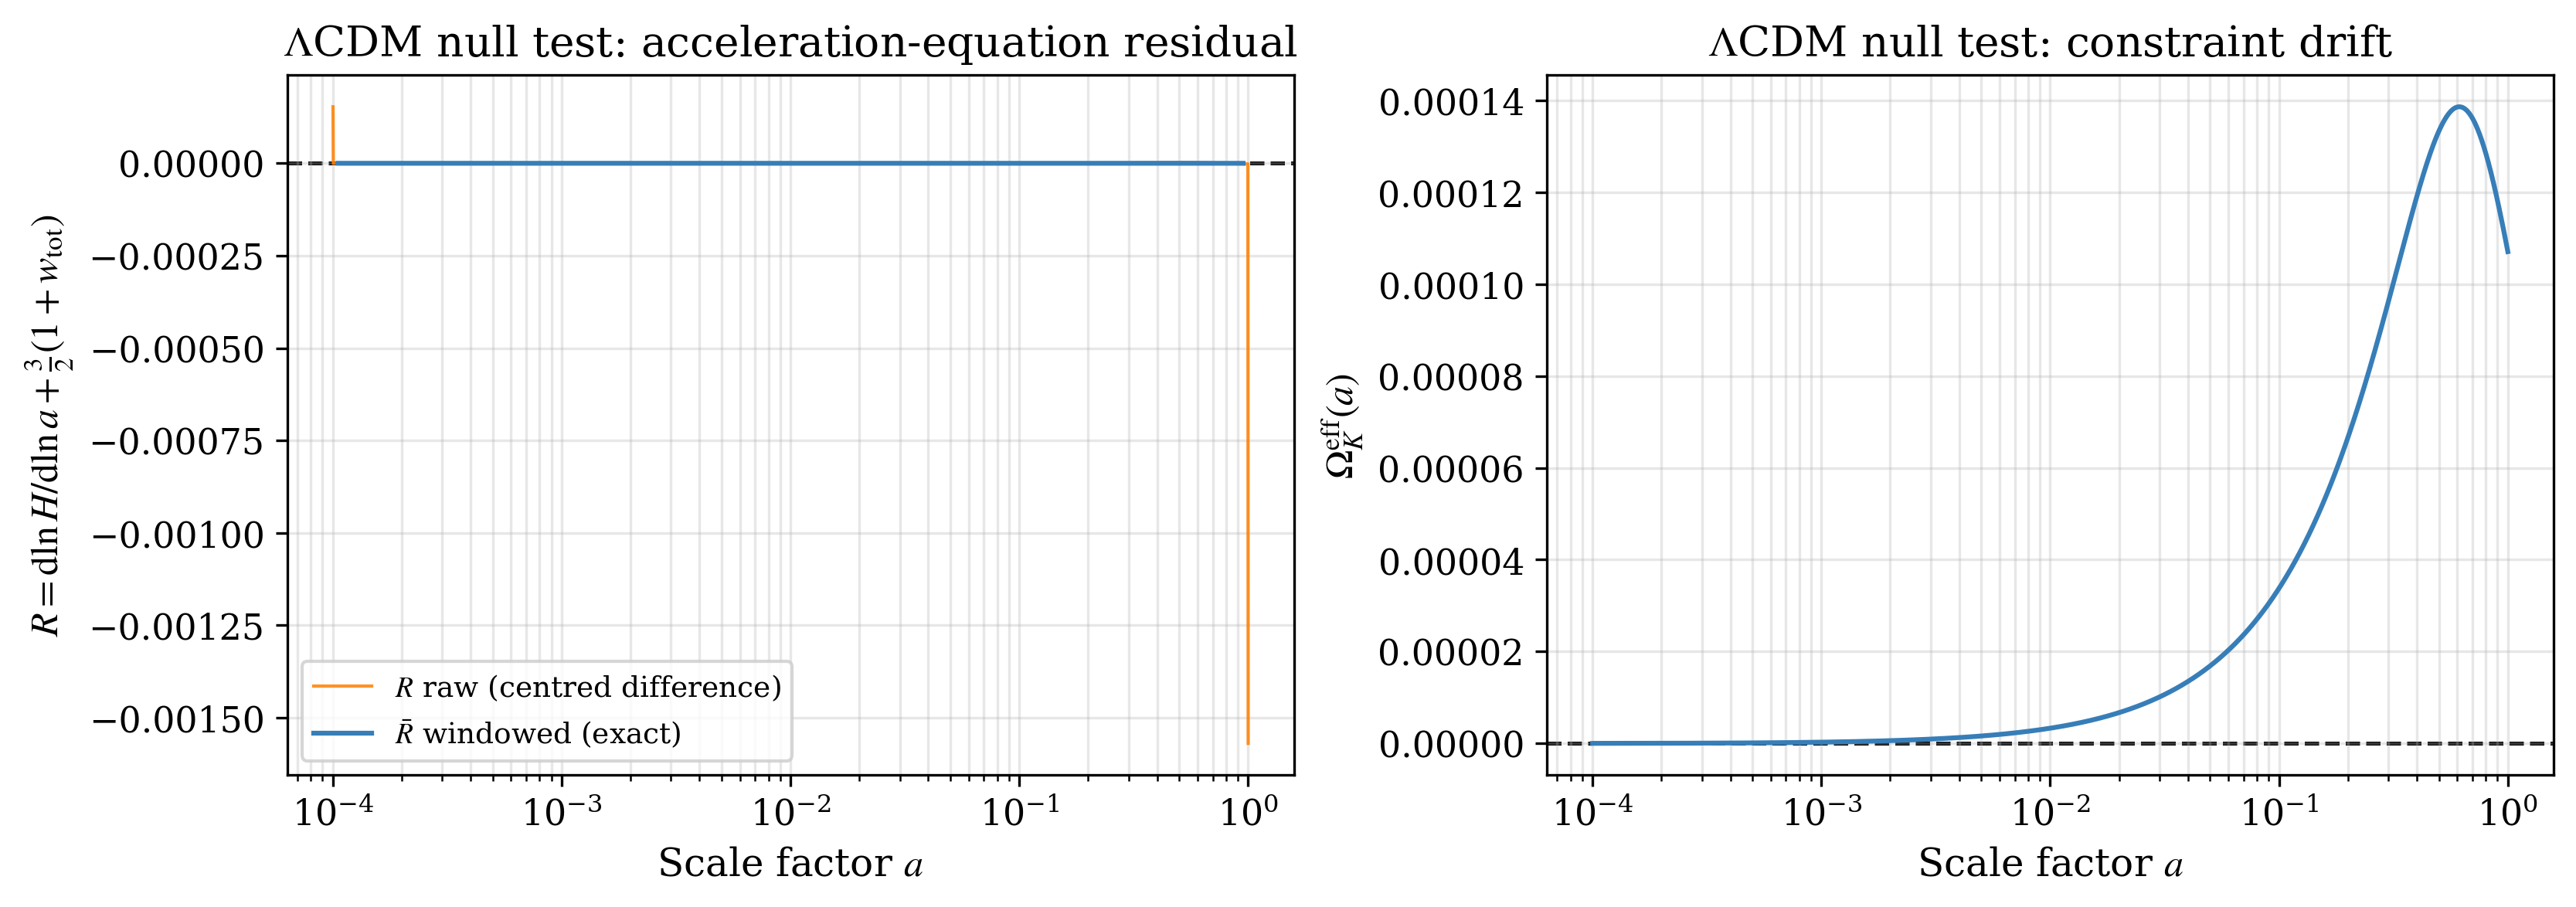

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

ax = axes[0]
ax.semilogx(tab_lcdm['a'], tab_lcdm['R_raw'], color=qual_colors[1], alpha=0.85,
            linewidth=1.0, label=r'$R$ raw (centred difference)')
ax.semilogx(a_win_l, R_win_l, color=qual_colors[0], label=r'$\bar R$ windowed (exact)')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$R = \mathrm{d}\ln H/\mathrm{d}\ln a + \frac{3}{2}(1+w_{\mathrm{tot}})$')
ax.set_title(r'$\Lambda$CDM null test: acceleration-equation residual')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogx(tab_lcdm['a'], tab_lcdm['OmegaK'], color=qual_colors[0])
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Omega_K^{\mathrm{eff}}(a)$')
ax.set_title(r'$\Lambda$CDM null test: constraint drift')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## 3. D1 on accDM - pointwise residual $R(a)$

Fiducial point (edit `FIDUCIAL` freely). Three curves are shown:

- **$R$ raw** - centred difference. Expect a spike comb: this is the ncdm staircase aliasing, not
  a bug in the estimator. Between spikes it sits at $-aQ_0/(2\rho_{\rm tot}\mathcal{H})$, i.e. the
  parent draining with the daughter not yet receiving.
- **$\bar R$ windowed** - the exact coarse-grained residual. This is the number to read.
- **$R_{\rm pred}$** - $\eta\,a Q_0/(2\rho_{\rm tot}\mathcal{H})$ from the code's own
  `Gamma_acc` and `(.)rho_acc_cdm`, no differentiation.

If $\bar R \approx R_{\rm pred}$, the code is doing exactly what section 0 says it is doing, and the
$(1+\eta)$ asymmetry is confirmed dynamically rather than by reading source.


In [5]:
FIDUCIAL = dict(f_acc=0.1, eta=0.1, kappa=12.1, a_t=0.133)

bg_acc  = run_background(accdm_params(**FIDUCIAL))
tab_acc = conservation_tables(bg_acc, eta=FIDUCIAL['eta'])
a_win, R_win, _ = windowed_residual(tab_acc)

R_pred_on_win = np.interp(a_win, tab_acc['a'], tab_acc['R_pred'])
band = R_pred_on_win > 0.05*np.max(R_pred_on_win)     # where injection actually happens

print('accDM fiducial:', FIDUCIAL)
print('  units self-test max|H^2/rho-1| : {:.3e}'.format(tab_acc['units_residual']))
print('  max |R_pred|                   : {:.4e}  at a = {:.4f}'.format(
      float(np.max(np.abs(tab_acc['R_pred']))),
      float(tab_acc['a'][int(np.argmax(np.abs(tab_acc['R_pred'])))])))
print('  max |R_windowed|               : {:.4e}  at a = {:.4f}'.format(
      float(np.max(np.abs(R_win))), float(a_win[int(np.argmax(np.abs(R_win)))])))
print('  max |R_raw|                    : {:.4e}   <- aliased by the ncdm staircase'.format(
      float(np.max(np.abs(tab_acc['R_raw'])))))
if band.sum() > 0:
    ratio = R_win[band]/R_pred_on_win[band]
    print('  R_windowed / R_pred over the injection band:')
    print('     median {:.4f}   min {:.4f}   max {:.4f}'.format(
          float(np.median(ratio)), float(np.min(ratio)), float(np.max(ratio))))


accDM fiducial: {'f_acc': 0.1, 'eta': 0.1, 'kappa': 12.1, 'a_t': 0.133}
  units self-test max|H^2/rho-1| : 2.220e-16
  max |R_pred|                   : 1.1435e-02  at a = 0.1329
  max |R_windowed|               : 1.5878e-02  at a = 0.1325
  max |R_raw|                    : 6.5312e-02   <- aliased by the ncdm staircase
  R_windowed / R_pred over the injection band:
     median 0.9054   min 0.5430   max 1.7159


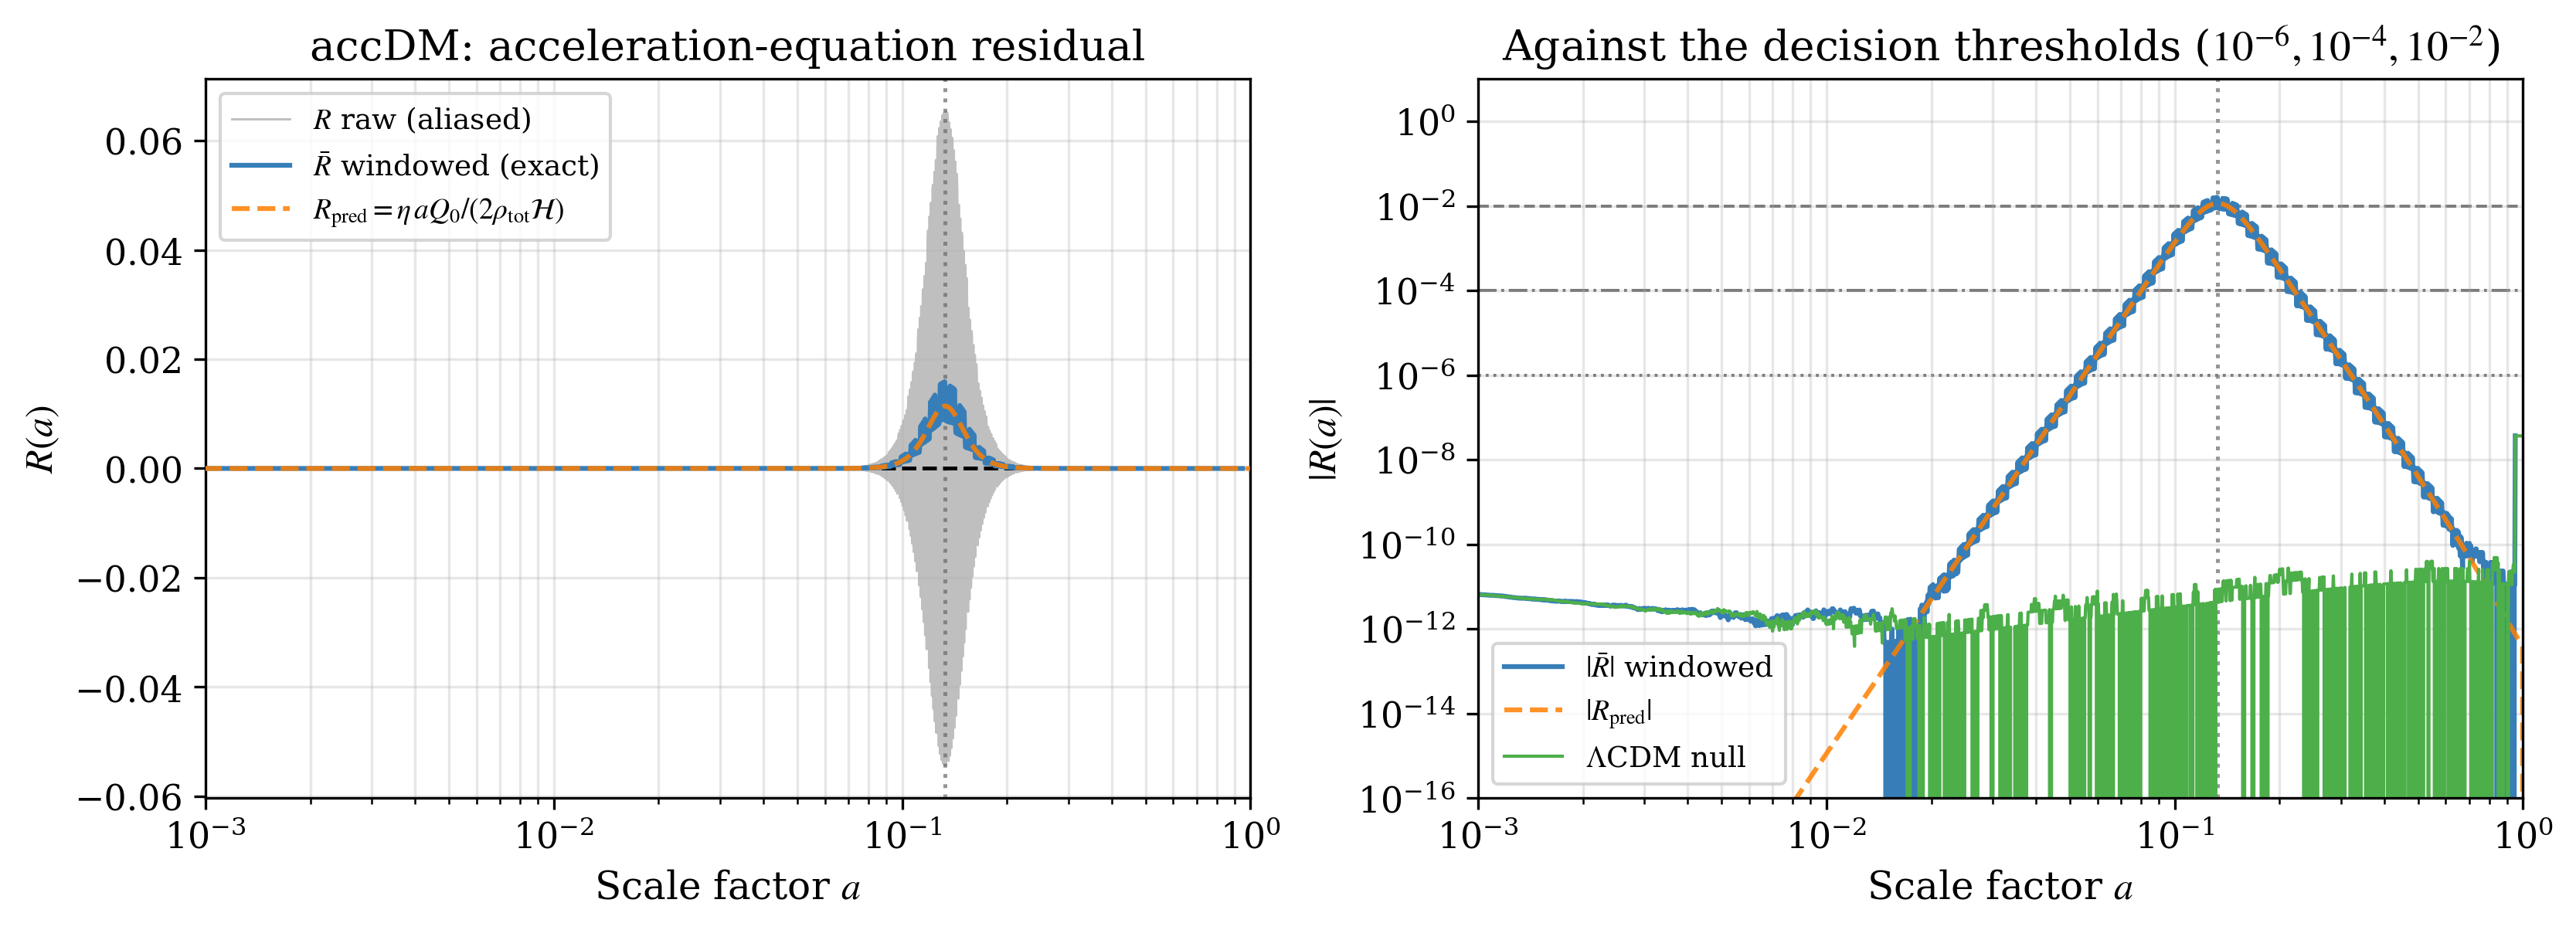

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), constrained_layout=True)

ax = axes[0]
ax.semilogx(tab_acc['a'], tab_acc['R_raw'], color='0.75', linewidth=0.7,
            label=r'$R$ raw (aliased)', zorder=1)
ax.semilogx(a_win, R_win, color=qual_colors[0], label=r'$\bar R$ windowed (exact)', zorder=3)
ax.semilogx(tab_acc['a'], tab_acc['R_pred'], color=qual_colors[1], alpha=0.85,
            linestyle='--', label=r'$R_{\mathrm{pred}} = \eta\, aQ_0/(2\rho_{\mathrm{tot}}\mathcal{H})$',
            zorder=4)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=2)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(1e-3, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$R(a)$')
ax.set_title(r'accDM: acceleration-equation residual')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.loglog(a_win, np.abs(R_win), color=qual_colors[0], label=r'$|\bar R|$ windowed')
ax.loglog(tab_acc['a'], np.abs(tab_acc['R_pred']), color=qual_colors[1], alpha=0.85,
          linestyle='--', label=r'$|R_{\mathrm{pred}}|$')
ax.loglog(tab_lcdm['a'], np.abs(np.interp(tab_lcdm['a'], a_win_l, R_win_l)),
          color=qual_colors[2], linewidth=1.0, label=r'$\Lambda$CDM null')
for level, style in ((1e-6, ':'), (1e-4, '-.'), (1e-2, '--')):
    ax.axhline(level, color='black', linestyle=style, linewidth=0.9, alpha=0.6, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(1e-3, 1.0)
ax.set_ylim(1e-16, 1e1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|R(a)|$')
ax.set_title(r'Against the decision thresholds ($10^{-6},10^{-4},10^{-2}$)')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## 4. D2 - manufactured curvature across the parameter space

$\mathrm{d}K/\mathrm{d}\tau = \tfrac{8\pi G}{3}a^3\eta Q_0$, so $K^{\rm eff}$ is *permanent*: unlike
the daughter's kinetic energy, which redshifts away after injection, the constraint violation
accumulated during injection stays. In matter domination $\Omega_K^{\rm eff}\propto a$ thereafter.

Edit `SCAN_POINTS`. The second entry uses the code's own default $\eta = 10^{11}/m_{\rm acc}$
(`input.c:2643`); the third is a deliberately aggressive corner (large $\kappa f_{\rm acc}\eta$) to
bracket the prior volume. Compare $\Omega_K^{\rm eff}(1)$ against Planck 2018 + BAO,
$\Omega_K = 0.0007 \pm 0.0019$.


In [26]:
SCAN_POINTS = [
    ('fiducial',                 dict(f_acc=0.1, eta=0.1,   kappa=12.1, a_t=0.133)),
    ('eta = 1e11/m (default)',   dict(f_acc=0.1, eta=1e-5,  kappa=12.1, a_t=0.133)),
    ('aggressive corner',        dict(f_acc=1.0, eta=0.5,   kappa=12.1, a_t=0.133)),
    ('a_t = 0.02',               dict(f_acc=0.1, eta=0.1,   kappa=12.1, a_t=0.02)),
    ('a_t = 0.05',               dict(f_acc=0.1, eta=0.1,   kappa=12.1, a_t=0.05)),
    ('a_t = 0.40',               dict(f_acc=0.1, eta=0.1,   kappa=12.1, a_t=0.40)),
]

scan_results = {}
print('{:<24} {:>7} {:>7} {:>7} {:>7} {:>12} {:>10} {:>14}'.format(
      'point', 'f_acc', 'eta', 'kappa', 'a_t', 'max|R_win|', 'at a', 'Omega_K_eff(1)'))
print('-'*98)
for label, pars in SCAN_POINTS:
    bg  = run_background(accdm_params(**pars))
    tab = conservation_tables(bg, eta=pars['eta'])
    a_w, R_w, _ = windowed_residual(tab)
    i_peak = int(np.argmax(np.abs(R_w)))
    scan_results[label] = dict(pars=pars, tab=tab, a_win=a_w, R_win=R_w,
                               R_max=float(np.abs(R_w[i_peak])),
                               a_at_max=float(a_w[i_peak]),
                               OmegaK1=float(tab['OmegaK'][-1]))
    r = scan_results[label]
    print('{:<24} {:>7.2f} {:>7.1e} {:>7.1f} {:>7.3f} {:>12.4e} {:>10.4f} {:>+14.4e}'.format(
          label, pars['f_acc'], pars['eta'], pars['kappa'], pars['a_t'],
          r['R_max'], r['a_at_max'], r['OmegaK1']))

print('\nLCDM null for reference: max|R_win| = {:.3e}, Omega_K_eff(1) = {:+.3e}'.format(
      float(np.max(np.abs(R_win_l))), float(tab_lcdm['OmegaK'][-1])))
print('Planck 2018 + BAO: Omega_K = 0.0007 +/- 0.0019')


point                      f_acc     eta   kappa     a_t   max|R_win|       at a Omega_K_eff(1)
--------------------------------------------------------------------------------------------------
fiducial                    0.10 1.0e-01    12.1   0.133   1.5878e-02     0.1325    +1.8451e-02
eta = 1e11/m (default)      0.10 1.0e-05    12.1   0.133   4.3886e-03     0.1325    +1.2721e-04
aggressive corner           1.00 5.0e-01    12.1   0.133   3.1482e-01     0.1325    +5.0416e-01
a_t = 0.02                  0.10 1.0e-01    12.1   0.020   1.5740e-02     0.0204    +1.2210e-01
a_t = 0.05                  0.10 1.0e-01    12.1   0.050   1.5961e-02     0.0504    +4.8902e-02
a_t = 0.40                  0.10 1.0e-01    12.1   0.400   1.4022e-02     0.3965    +6.2065e-03

LCDM null for reference: max|R_win| = 4.595e-08, Omega_K_eff(1) = +1.071e-04
Planck 2018 + BAO: Omega_K = 0.0007 +/- 0.0019


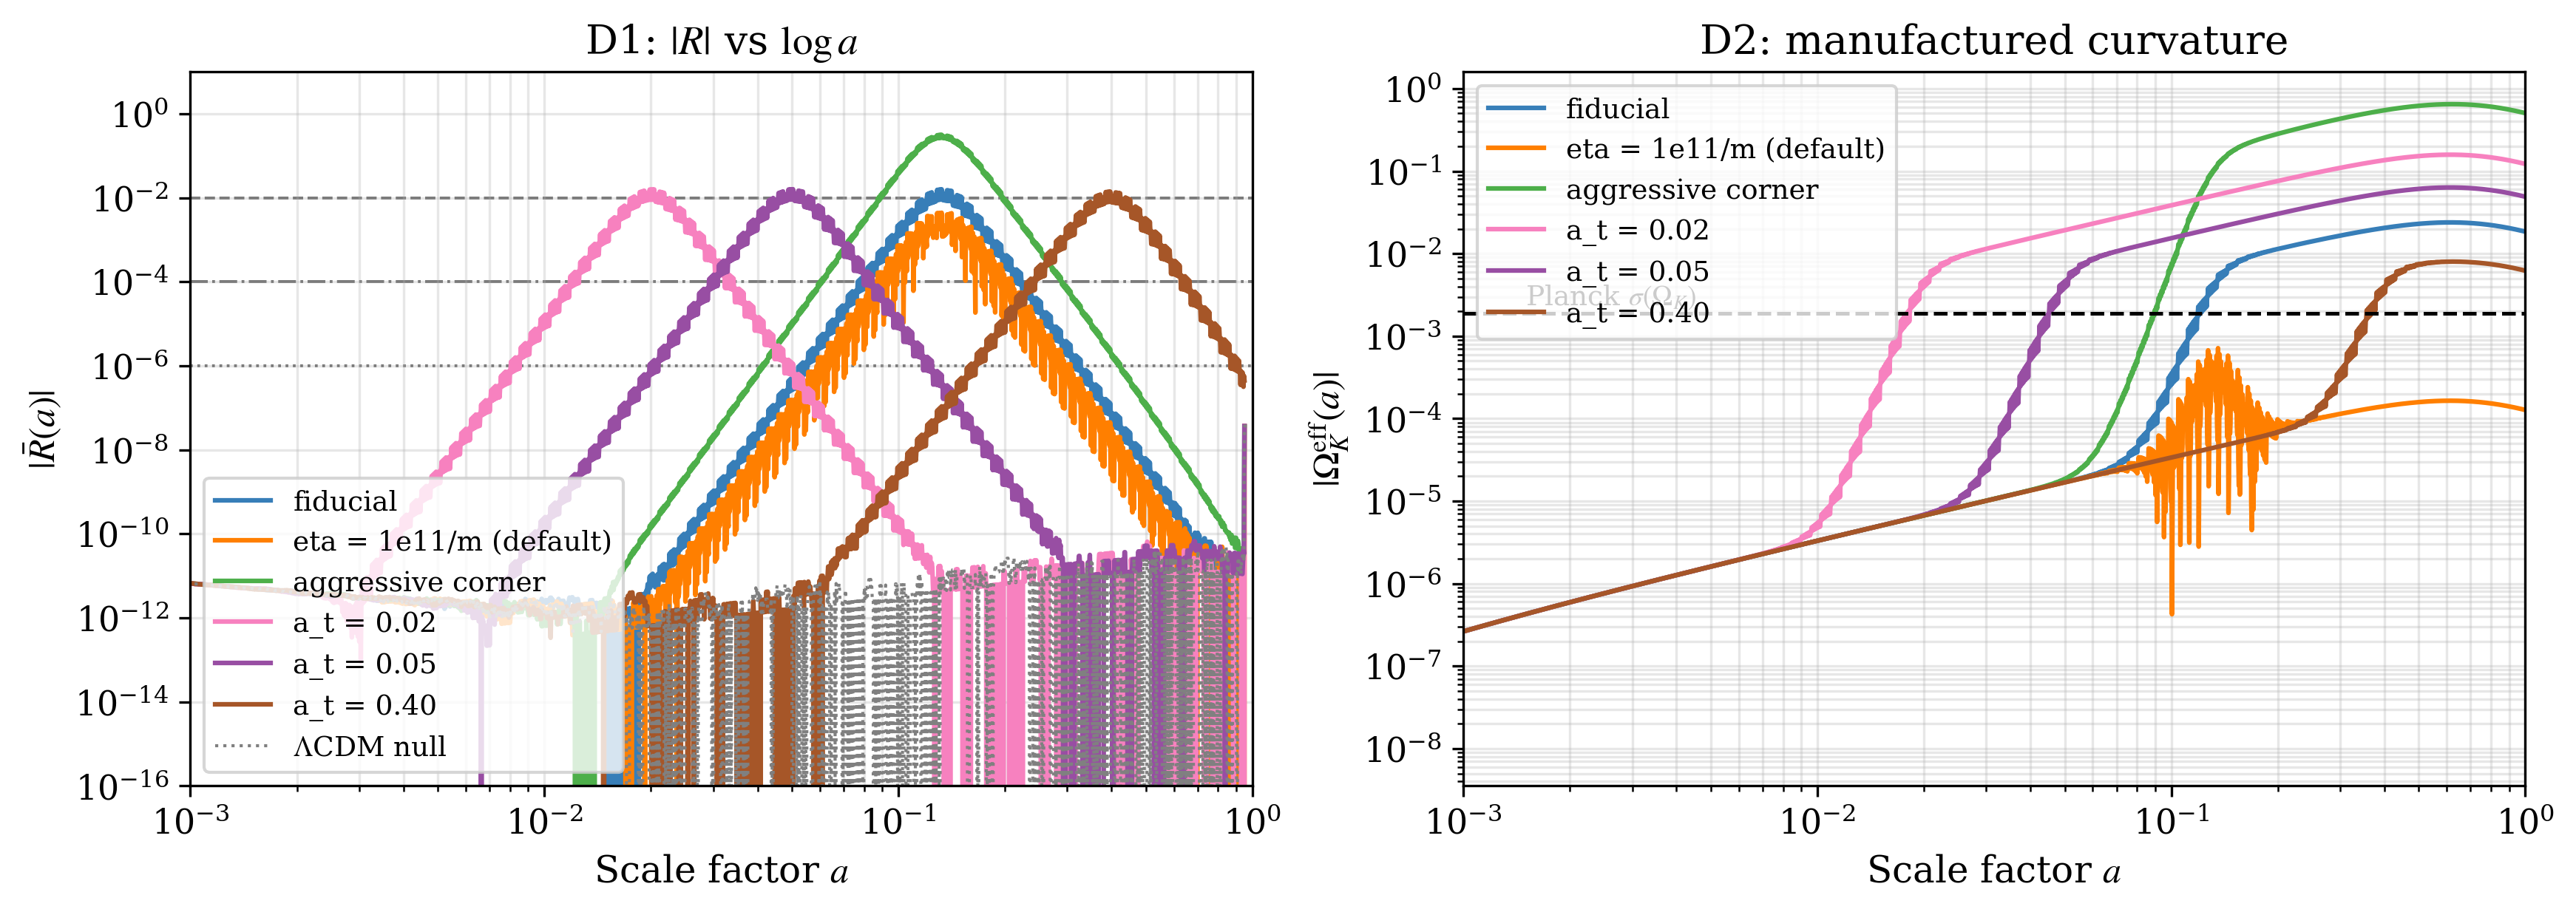

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
palette = qual_colors + ['#a65628']

ax = axes[0]
for color, (label, _) in zip(palette, SCAN_POINTS):
    r = scan_results[label]
    ax.loglog(r['a_win'], np.abs(r['R_win']), color=color, label=label)
ax.loglog(tab_lcdm['a'], np.abs(np.interp(tab_lcdm['a'], a_win_l, R_win_l)),
          color='0.5', linewidth=1.0, linestyle=':', label=r'$\Lambda$CDM null')
for level, style in ((1e-6, ':'), (1e-4, '-.'), (1e-2, '--')):
    ax.axhline(level, color='black', linestyle=style, linewidth=0.9, alpha=0.6, zorder=1)
ax.set_xlim(1e-3, 1.0)
ax.set_ylim(1e-16, 1e1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\bar R(a)|$')
ax.set_title(r'D1: $|R|$ vs $\log a$')
ax.legend(loc='lower left')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for color, (label, _) in zip(palette, SCAN_POINTS):
    r = scan_results[label]
    ax.loglog(r['tab']['a'], np.abs(r['tab']['OmegaK']), color=color, label=label)
ax.axhline(0.0019, color='black', linestyle='--', linewidth=1.2, zorder=2)
ax.text(1.5e-3, 2.4e-3, r'Planck $\sigma(\Omega_K)$', fontsize=9)
ax.set_xlim(1e-3, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\Omega_K^{\mathrm{eff}}(a)|$')
ax.set_title(r'D2: manufactured curvature')
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## 4b. D3 - integrate the acceleration equation directly

**This supersedes D2 and improves D1.** Instead of reconstructing the violation from
$\rho_{\rm tot}$ and $p_{\rm tot}$ and then comparing against a differentiated $H$, carry the second
Friedmann equation as an auxiliary variable along the code's own trajectory:

$$\frac{\mathrm{d}\mathcal{H}_B}{\mathrm{d}\tau} = -\frac{4\pi G}{3}a^2(\rho_{\rm tot}+3p_{\rm tot}),
\qquad \mathcal{H}_B(\tau_{\rm ini}) = \mathcal{H}_A(\tau_{\rm ini}),$$

started well before $a_t$, and report the accumulated fractional error in the expansion rate

$$\Delta(a) = \frac{\mathcal{H}_B(a)-\mathcal{H}_A(a)}{\mathcal{H}_A(a)},$$

against the code's own constraint-derived $\mathcal{H}_A = a H$. Since $H$ and $\mathcal{H}$ differ
by the common factor $a$, $\Delta$ is the same number for either. Nothing is differentiated
anywhere, so the ncdm staircase cannot alias it.

**Three things worth noting about the implementation.**

1. *It is a quadrature, not an ODE.* The right-hand side depends only on $a$, $\rho_{\rm tot}$,
   $p_{\rm tot}$ - all tabulated - and not on $\mathcal{H}_B$ itself. So no integrator is needed,
   just a high-order cumulative quadrature. Changing variable to $x=\ln a$ with the code's own
   Jacobian $\mathrm{d}\tau/\mathrm{d}x = 1/\mathcal{H}_A$ gives

   $$\mathcal{H}_B(x) = \mathcal{H}_A(x_0) - \int_{x_0}^{x}\frac{a^2}{2\mathcal{H}_A}\bigl(\rho_{\rm tot}+3p_{\rm tot}\bigr)\,\mathrm{d}x'$$

   in CLASS units, and $x$ is the grid CLASS actually integrates on (uniform), which is what a
   high-order rule wants. This is *identical* to integrating in $\tau$, and the cell below proves it
   by reconstructing the table's own conformal-time column as $\tau(x)=\tau_0+\int\mathrm{d}x/\mathcal{H}_A$
   - a differentiation-free self-test of both the Jacobian and the quadrature.

2. *Why it is better conditioned than D2, concretely.* Both diagnostics cancel a large early-time
   quantity against a large integral, but at very different rates. D2 forms
   $K^{\rm eff} = \Delta(a^2\rho_{\rm tot}) + \int a^2(\rho+3p)\,\mathrm{d}x$, whose terms are
   $O(\mathcal{H}_i^2)$, so the cancellation scales as $(\mathcal{H}_i/\mathcal{H})^2 \propto a_i^{-2}$
   in radiation domination. D3's terms are $O(\mathcal{H}_i)$, so it scales as $a_i^{-1}$ - one power
   better. That is exactly what section 2's `A_START` scan showed: the D2 floor fell ~100x per decade
   of `A_START` (1.03e-2, 1.07e-4, 1.45e-6, 4.68e-8), i.e. it was still cancellation-limited at
   `A_START=1e-4`. D3 should degrade only ~10x per decade; the cell below scans it so you can check
   rather than believe.

3. *Consistency with D2.* $\mathcal{H}_B^2-\mathcal{H}_A^2 = -K^{\rm eff}$ to leading order, hence
   $\Delta \simeq -\tfrac12\Omega_K^{\rm eff}$. The two formulations are printed side by side below;
   they are independent quadratures of different integrands, so agreement is a real cross-check.

**It also fixes D1.** Because
$\mathrm{d}(\mathcal{H}_A-\mathcal{H}_B)/\mathrm{d}x = a^2W/(2\mathcal{H}_A) = R\,\mathcal{H}_A$,
the exact $\mathcal{H}_A$-weighted mean of $R$ over any window is

$$\bar R = \frac{(\mathcal{H}_A-\mathcal{H}_B)\big|_{x_a}^{x_b}}{\int_{x_a}^{x_b}\mathcal{H}_A\,\mathrm{d}x},$$

which is the same windowed estimator as section 3 but built on the better-conditioned integral, with
no $a^2\rho_{\rm tot}$ boundary term.


In [ ]:
try:
    from scipy.interpolate import CubicSpline
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

A_START_D3 = 1e-3      # well before the earliest a_t in SCAN_POINTS


def cum_spline(y, x):
    '''Cumulative integral as the antiderivative of a cubic spline: O(h^4).'''
    F = CubicSpline(x, y).antiderivative()
    return F(x) - F(x[0])


def cum_best(y, x):
    return cum_spline(y, x) if HAVE_SCIPY else cum_integral(y, x)


def analytic_lcdm_selftest(a_start=A_START_D3, n=20001,
                           Om=0.31, Or=9.1e-5, OL=0.68991):
    '''Unit test of the D3 integrand on an ANALYTIC flat LCDM background (H0=1).

    Nothing here comes from CLASS, so any sign or factor error in dHcal_B/dx shows
    up immediately. Returns max |Delta|, which must be at quadrature level.'''
    x   = np.linspace(np.log(a_start), 0.0, n)
    a   = np.exp(x)
    rho = Om/a**3 + Or/a**4 + OL
    p   = Or/(3.0*a**4) - OL
    Hcal_A = a*np.sqrt(rho)
    dHB_dx = -(a**2)*(rho + 3.0*p)/(2.0*Hcal_A)
    Hcal_B = Hcal_A[0] + cum_best(dHB_dx, x)
    return float(np.max(np.abs(Hcal_B/Hcal_A - 1.0)))


def acceleration_integration(bg, a_start=A_START_D3):
    '''D3: carry Friedmann II as an auxiliary variable along the code's trajectory.

    Returns Delta = Hcal_B/Hcal_A - 1, plus two self-checks:
      tau_selftest     : reconstruct the table's conformal time from int dx/Hcal_A
      quad_uncertainty : spread between the spline and Euler-Maclaurin quadratures
    '''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]

    a, H   = a_all[order], take('H [1/Mpc]')
    rho, p = take('(.)rho_tot'), take('(.)p_tot')
    tau    = take('conf. time [Mpc]')

    sel = a >= a_start
    a, H, rho, p, tau = a[sel], H[sel], rho[sel], p[sel], tau[sel]
    x = np.log(a)
    Hcal_A = a*H

    # dHcal_B/dx = (dHcal_B/dtau)*(dtau/dx),  dtau/dx = 1/Hcal_A
    dHB_dx = -(a**2)*(rho + 3.0*p)/(2.0*Hcal_A)

    Hcal_B     = Hcal_A[0] + cum_best(dHB_dx, x)
    Hcal_B_alt = Hcal_A[0] + cum_integral(dHB_dx, x)
    Delta      = Hcal_B/Hcal_A - 1.0

    tau_recon = tau[0] + cum_best(1.0/Hcal_A, x)
    tau_selftest = float(np.max(np.abs(tau_recon[1:]/tau[1:] - 1.0)))

    D    = Hcal_A - Hcal_B
    Icum = cum_best(Hcal_A, x)

    return dict(a=a, x=x, Hcal_A=Hcal_A, Hcal_B=Hcal_B, Delta=Delta, D=D, Icum=Icum,
                tau_selftest=tau_selftest,
                quad_uncertainty=float(np.max(np.abs(Hcal_B_alt/Hcal_A - 1.0 - Delta))))


def windowed_R_d3(acc, half_width_efolds=0.05):
    '''Exact Hcal_A-weighted window mean of R, built on the D3 integral.'''
    x, D, Icum = acc['x'], acc['D'], acc['Icum']
    dx = float(np.median(np.diff(x)))
    m  = max(1, int(round(half_width_efolds/dx)))
    i  = np.arange(m, len(x) - m)
    return acc['a'][i], (D[i + m] - D[i - m])/(Icum[i + m] - Icum[i - m])


acc_lcdm = acceleration_integration(bg_lcdm)
acc_fid  = acceleration_integration(bg_acc)

print('D3 - direct integration of the acceleration equation')
print('  quadrature            : {}'.format('cubic-spline antiderivative (O(h^4))'
                                            if HAVE_SCIPY else 'Euler-Maclaurin trapezoid'))

selftest = analytic_lcdm_selftest()
print('  analytic LCDM unit test: max|Delta| = {:.3e}  ->  {}'.format(
      selftest, 'signs and factors CORRECT' if selftest < 1e-9 else 'FORMULA IS WRONG'))
assert selftest < 1e-9, 'D3 integrand fails on an analytic LCDM background'
print()
print('  LCDM NULL')
print('    conf-time self-test : {:.3e}   (int dx/Hcal_A vs the table tau column)'.format(
      acc_lcdm['tau_selftest']))
print('    quadrature spread   : {:.3e}   (spline vs Euler-Maclaurin)'.format(
      acc_lcdm['quad_uncertainty']))
print('    Delta(a=1)          : {:+.3e}   <- NULL FLOOR'.format(float(acc_lcdm['Delta'][-1])))
print('    max |Delta(a)|      : {:.3e}'.format(float(np.max(np.abs(acc_lcdm['Delta'])))))
print()
print('  accDM fiducial', FIDUCIAL)
print('    conf-time self-test : {:.3e}'.format(acc_fid['tau_selftest']))
print('    quadrature spread   : {:.3e}'.format(acc_fid['quad_uncertainty']))
print('    Delta(a=1)          : {:+.3e}'.format(float(acc_fid['Delta'][-1])))
print('    -0.5*Omega_K_eff(1) : {:+.3e}   (D2, independent quadrature)'.format(
      -0.5*float(tab_acc['OmegaK'][-1])))
print('    D3/D2 ratio         : {:.4f}'.format(
      float(acc_fid['Delta'][-1])/(-0.5*float(tab_acc['OmegaK'][-1]))))

print('\n  A_START sensitivity - is D3 really better conditioned than D2?')
print('  {:>10} {:>16} {:>16} {:>10}'.format('A_START', 'D3 |Delta(1)|', 'D2 |OmK(1)|/2', 'D2/D3'))
for a0 in (1e-5, 1e-4, 1e-3, 1e-2):
    d3 = abs(float(acceleration_integration(bg_lcdm, a_start=a0)['Delta'][-1]))
    d2 = 0.5*abs(float(conservation_tables(bg_lcdm, eta=0.0, a_start=a0)['OmegaK'][-1]))
    print('  {:>10.0e} {:>16.3e} {:>16.3e} {:>10.1f}'.format(a0, d3, d2, d2/max(d3, 1e-300)))
print('  (D3 should degrade ~10x per decade, D2 ~100x: one power of a_i better)')


In [ ]:
d3_results = {}
print('running D3 over the scan points (one background run each)...')
for label, pars in SCAN_POINTS:
    bg = run_background(accdm_params(**pars))
    d3_results[label] = acceleration_integration(bg)
    print('  done: {:<24} Delta(1) = {:+.4e}'.format(label, float(d3_results[label]['Delta'][-1])))

print()
print('{:<24} {:>14} {:>18} {:>10} {:>12}'.format(
      'point', 'Delta(1)', '-0.5*Omega_K_eff(1)', 'D3/D2', 'max|Delta|'))
print('-' * 82)
for label, _ in SCAN_POINTS:
    d3 = float(d3_results[label]['Delta'][-1])
    d2 = -0.5*scan_results[label]['OmegaK1']
    print('{:<24} {:>+14.4e} {:>+18.4e} {:>10.4f} {:>12.4e}'.format(
          label, d3, d2, d3/d2 if d2 != 0 else float('nan'),
          float(np.max(np.abs(d3_results[label]['Delta'])))))
print()
print('LCDM null floor: Delta(1) = {:+.3e}'.format(float(acc_lcdm['Delta'][-1])))
print('Planck-equivalent threshold |Delta| = sigma(Omega_K)/2 = 9.5e-4')
print()
print('Interpretation: Delta < 0 means the code expands FASTER than the acceleration')
print('equation allows, which is what creating energy from nothing does.')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
palette = qual_colors + ['#a65628']

ax = axes[0]
for color, (label, _) in zip(palette, SCAN_POINTS):
    ax.semilogx(d3_results[label]['a'], 100.0*d3_results[label]['Delta'], color=color, label=label)
ax.semilogx(acc_lcdm['a'], 100.0*acc_lcdm['Delta'], color='0.5', linestyle=':',
            linewidth=1.0, label=r'$\Lambda$CDM null')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlim(A_START_D3, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Delta = (\mathcal{H}_B-\mathcal{H}_A)/\mathcal{H}_A$  [%]')
ax.set_title(r'D3: accumulated fractional error in $H$')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for color, (label, _) in zip(palette, SCAN_POINTS):
    ax.loglog(d3_results[label]['a'], np.abs(d3_results[label]['Delta']), color=color, label=label)
ax.loglog(acc_lcdm['a'], np.abs(acc_lcdm['Delta']), color='0.5', linestyle=':',
          linewidth=1.0, label=r'$\Lambda$CDM null')
ax.axhline(9.5e-4, color='black', linestyle='--', linewidth=1.2, zorder=2)
ax.text(1.3e-3, 1.15e-3, r'Planck $\sigma(\Omega_K)/2$', fontsize=9)
ax.set_xlim(A_START_D3, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\Delta|$')
ax.set_title(r'D3 against the curvature bound')
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.show()

# the windowed R rebuilt on the D3 integral - same quantity as section 3, better conditioned
a_r3, R_win3 = windowed_R_d3(acc_fid)
a_r3_null, R_win3_null = windowed_R_d3(acc_lcdm)
print('windowed R from D3 (fiducial): max = {:.4e} at a = {:.4f}'.format(
      float(np.max(np.abs(R_win3))), float(a_r3[int(np.argmax(np.abs(R_win3)))])))
print('windowed R from D3 (LCDM null): max = {:.4e}'.format(float(np.max(np.abs(R_win3_null)))))
print('section 3 value for comparison : max = {:.4e}'.format(float(np.max(np.abs(R_win)))))


## 5. Closed-form background cross-check

This is the part that does **not** trust CLASS's ncdm quadrature at all, and it is where the
$(1+\eta)$ shows up as a number rather than as source code.

Particles injected at $a'$ carry comoving momentum $a' P_{\rm acc}$ and rest mass $m_{\rm acc}$, so
at a later $a$ their physical momentum is $(a'/a)P_{\rm acc}$. Number conservation with the
**parent** mass $m_c$ gives the injection kernel (in CLASS density units)

$$\frac{\mathrm{d}\mathcal{N}}{\mathrm{d}a'} \;=\; \frac{a'^2\,\Gamma_{\rm acc}(a')\,\rho_c(a')}{H(a')},
\qquad \mathcal{N}(a) \equiv a^3 n_{\rm acc}(a)\, m_c ,$$

which follows from $\mathrm{d}(a^3 n_c)/\mathrm{d}a = -a^2\Gamma n_c/H$ alone. Then, with
$\mu = m_{\rm acc}/m_c$ and $v = P_{\rm acc}/m_{\rm acc}$,

$$\rho_{\rm acc}(a) = \frac{\mu}{a^3}\!\int_0^a\!\!\mathrm{d}a'\,\frac{\mathrm{d}\mathcal{N}}{\mathrm{d}a'}\sqrt{1+(a'/a)^2v^2},\quad
P_{\rm acc}(a) = \frac{\mu}{3a^3}\!\int_0^a\!\!\mathrm{d}a'\,\frac{\mathrm{d}\mathcal{N}}{\mathrm{d}a'}\frac{(a'/a)^2v^2}{\sqrt{1+(a'/a)^2v^2}},$$

$$\tilde p_{\rm acc}(a) = \frac{\mu}{3a^3}\!\int_0^a\!\!\mathrm{d}a'\,\frac{\mathrm{d}\mathcal{N}}{\mathrm{d}a'}\frac{(a'/a)^4v^4}{\bigl(1+(a'/a)^2v^2\bigr)^{3/2}}.$$

*(The task sheet writes these with an $a'^3$ kernel; the correct power is $a'^2$ - check it against
the $v\to0$ limit, which must reproduce $\rho' = -3\mathcal{H}\rho + aQ_0$ exactly. The cell below
verifies that limit numerically before using the kernel for anything else.)*

**The smoking gun.** At the instant of injection $a'\to a$ the energy factor is
$\sqrt{1+v^2}$, and with the code's defaults $\mu=1$, $v=\sqrt{\eta(\eta+2)}$, so
$\sqrt{1+v^2} = 1+\eta$ exactly. The parent gives up $m_c$; the daughter is born with
$(1+\eta)m_c$. The cell prints this ratio from the code's own `P_acc` construction.


In [9]:
def closed_form_moments(tab, a_eval, eta, mu=1.0, n_sub=4000):
    '''Independent quadrature for rho_acc, P_acc, pseudo_p_acc from the injection history.
    Uses only the code's Gamma_acc, rho_acc_cdm and H columns - no ncdm machinery.'''
    v = np.sqrt(eta*(eta + 2.0))/mu           # P_acc/m_acc, with P_acc built on m_c
    a_grid = tab['a']
    kernel = a_grid**2*tab['gamma_acc']*tab['rho_parent']/tab['H']

    rho_q, p_q, pp_q, num_q = [], [], [], []
    for a_now in a_eval:
        sel = a_grid <= a_now
        if sel.sum() < 4:
            rho_q.append(0.0); p_q.append(0.0); pp_q.append(0.0); num_q.append(0.0)
            continue
        ap, kp = a_grid[sel], kernel[sel]
        u  = (ap/a_now)**2*v**2                # (p_phys/m_acc)^2
        E  = np.sqrt(1.0 + u)
        rho_q.append(mu/a_now**3*trapz(kp*E, ap))
        p_q.append(mu/(3.0*a_now**3)*trapz(kp*u/E, ap))
        pp_q.append(mu/(3.0*a_now**3)*trapz(kp*u*u/E**3, ap))
        num_q.append(trapz(kp, ap))            # comoving rest-mass energy injected, /m_c
    return (np.array(rho_q), np.array(p_q), np.array(pp_q), np.array(num_q), v)


eta_fid = FIDUCIAL['eta']
d_idx   = daughter_index(bg_acc)
a_all   = 1.0/(1.0 + np.asarray(bg_acc['z']))
order   = np.argsort(a_all)
a_code  = a_all[order]
rho_d_code = np.asarray(bg_acc['(.)rho_ncdm[{:d}]'.format(d_idx)])[order]
p_d_code   = np.asarray(bg_acc['(.)p_ncdm[{:d}]'.format(d_idx)])[order]
pp_d_code  = np.asarray(bg_acc['(.)pseudo_p_ncdm[{:d}]'.format(d_idx)])[order]

a_eval = np.logspace(np.log10(max(FIDUCIAL['a_t']*0.5, 2e-2)), 0.0, 120)
rho_q, p_q, pp_q, num_q, v_inj = closed_form_moments(tab_acc, a_eval, eta_fid)

rho_d_i = np.interp(a_eval, a_code, rho_d_code)
p_d_i   = np.interp(a_eval, a_code, p_d_code)
pp_d_i  = np.interp(a_eval, a_code, pp_d_code)

good = rho_d_i > 0
dev_rho = np.abs(rho_q[good]/rho_d_i[good] - 1.0)
dev_w   = np.abs((p_q[good]/rho_q[good])/(p_d_i[good]/rho_d_i[good]) - 1.0)
dev_pp  = np.abs((pp_q[good]/p_q[good])/(pp_d_i[good]/p_d_i[good]) - 1.0)

print('SMOKING GUN - energy accounting per converted particle')
print('  v_inj = P_acc/m_acc                  : {:.6f}'.format(v_inj))
print('  E_inj/(m_c c^2) = sqrt(1+v^2)        : {:.6f}'.format(np.sqrt(1+v_inj**2)))
print('  1 + eta                              : {:.6f}'.format(1.0 + eta_fid))
print('  -> energy created per particle       : {:.4f} % of its rest mass'.format(100*eta_fid))
print()
print('CLOSED-FORM vs CLASS ncdm quadrature (fractional deviation over a in [{:.3f}, 1])'.format(a_eval[0]))
print('  rho_acc    : median {:.3e}   max {:.3e}'.format(float(np.median(dev_rho)), float(np.max(dev_rho))))
print('  w = P/rho  : median {:.3e}   max {:.3e}'.format(float(np.median(dev_w)), float(np.max(dev_w))))
print('  ptilde/P   : median {:.3e}   max {:.3e}'.format(float(np.median(dev_pp)), float(np.max(dev_pp))))

# v -> 0 sanity check on the kernel: the cold limit must be exactly a^-3 * int(kernel),
# which is the statement that rho' = -3 H rho + a Q0 holds with coefficient 1.
rho_cold, _, _, _, _ = closed_form_moments(tab_acc, a_eval, 0.0)
kern_full = tab_acc['a']**2*tab_acc['gamma_acc']*tab_acc['rho_parent']/tab_acc['H']
cold_direct = np.array([trapz(kern_full[tab_acc['a'] <= aa], tab_acc['a'][tab_acc['a'] <= aa])
                        for aa in a_eval])/a_eval**3
cold_ok = cold_direct > 0
print('\nkernel sanity (v=0 limit vs a^-3 * int kernel): max dev {:.3e}'.format(
      float(np.max(np.abs(rho_cold[cold_ok]/cold_direct[cold_ok] - 1.0)))))


SMOKING GUN - energy accounting per converted particle
  v_inj = P_acc/m_acc                  : 0.458258
  E_inj/(m_c c^2) = sqrt(1+v^2)        : 1.100000
  1 + eta                              : 1.100000
  -> energy created per particle       : 10.0000 % of its rest mass

CLOSED-FORM vs CLASS ncdm quadrature (fractional deviation over a in [0.066, 1])
  rho_acc    : median 1.576e-05   max 4.984e-02
  w = P/rho  : median 2.667e-05   max 7.317e-03
  ptilde/P   : median 4.808e-05   max 7.386e-03

kernel sanity (v=0 limit vs a^-3 * int kernel): max dev 2.220e-16


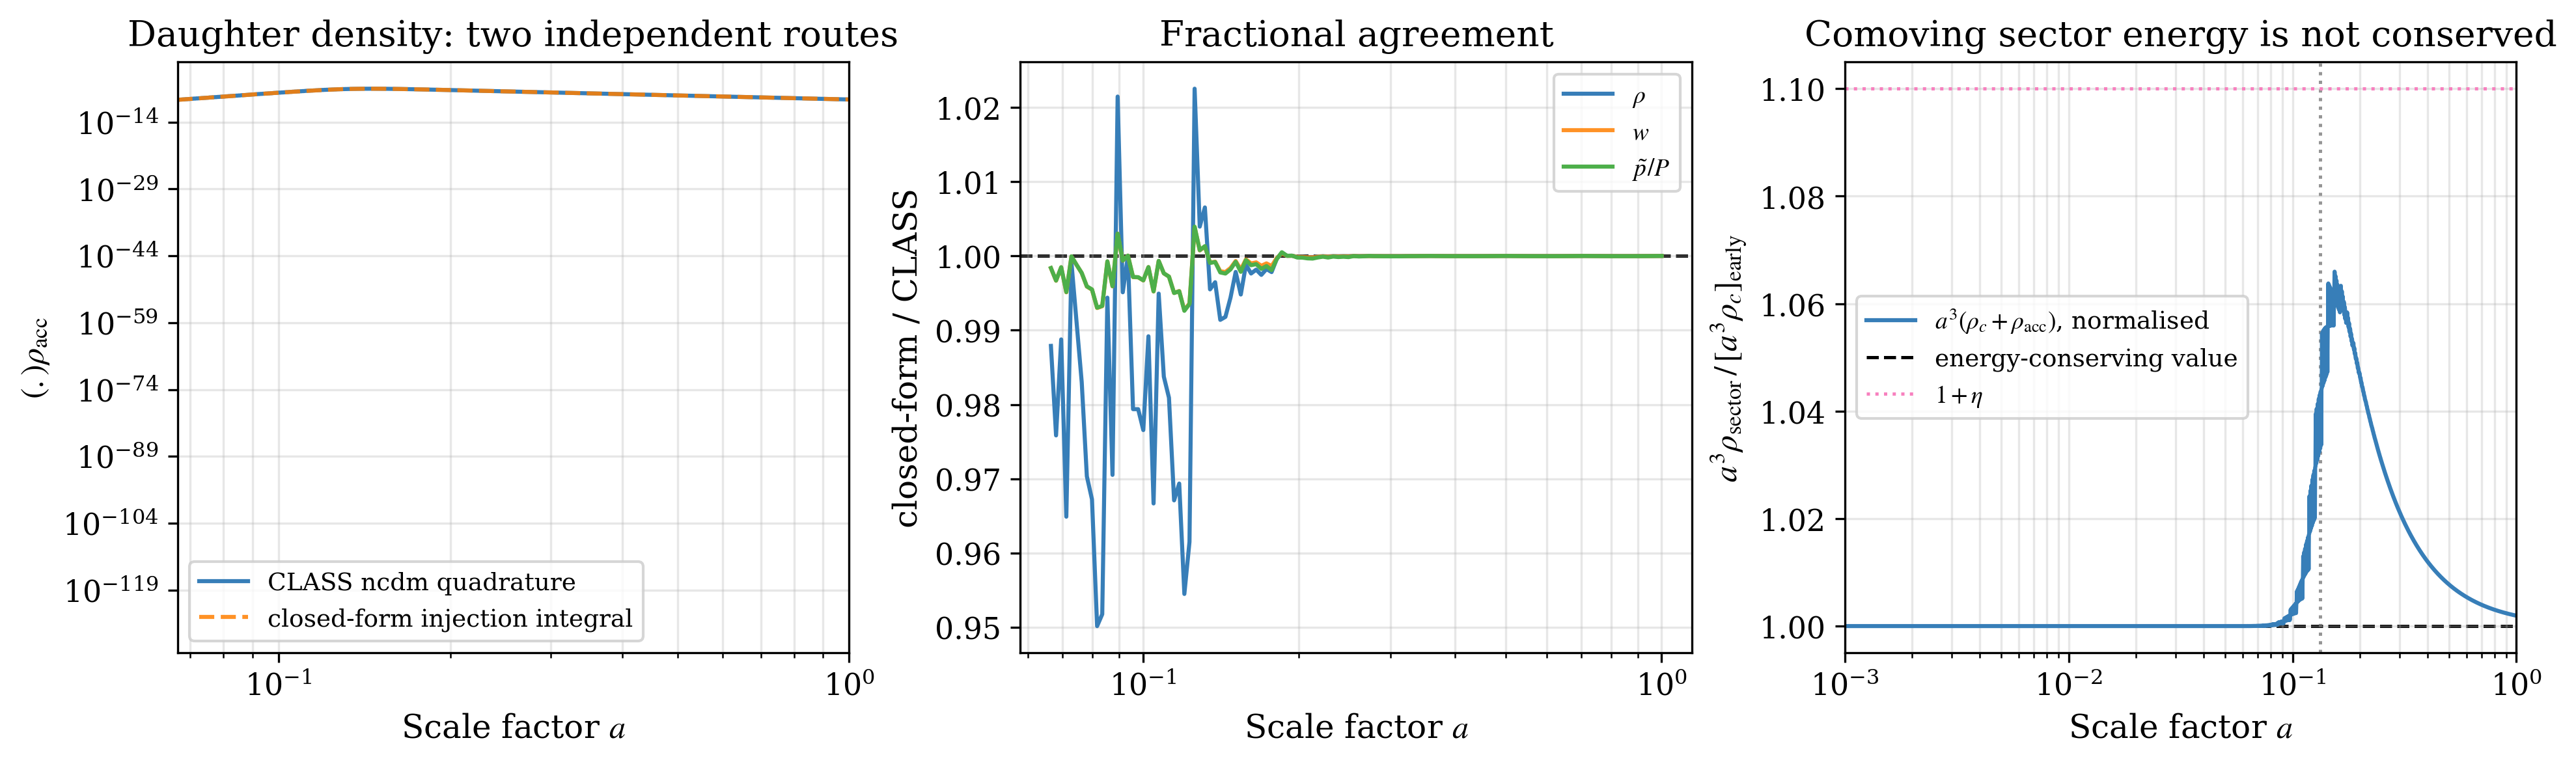

peak comoving-energy overshoot : 1.06595  (1+eta = 1.10000)
overshoot at a = 1             : 1.00194   <- kinetic part has redshifted away,
                                              but K_eff has not: see section 4


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)

ax = axes[0]
ax.loglog(a_code, rho_d_code, color=qual_colors[0], label='CLASS ncdm quadrature')
ax.loglog(a_eval, rho_q, color=qual_colors[1], alpha=0.85, linestyle='--',
          label='closed-form injection integral')
ax.set_xlim(a_eval[0], 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$(.)\rho_{\mathrm{acc}}$')
ax.set_title('Daughter density: two independent routes')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogx(a_eval[good], rho_q[good]/rho_d_i[good], color=qual_colors[0], label=r'$\rho$')
ax.semilogx(a_eval[good], (p_q[good]/rho_q[good])/(p_d_i[good]/rho_d_i[good]),
            color=qual_colors[1], alpha=0.85, label=r'$w$')
ax.semilogx(a_eval[good], (pp_q[good]/p_q[good])/(pp_d_i[good]/p_d_i[good]),
            color=qual_colors[2], label=r'$\tilde p / P$')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel('closed-form / CLASS')
ax.set_title('Fractional agreement')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[2]
comoving_total = a_code**3*(np.asarray(bg_acc['(.)rho_acc_cdm'])[order] + rho_d_code)
early = int(np.argmax(a_code > 1e-3))
ax.semilogx(a_code, comoving_total/comoving_total[early], color=qual_colors[0],
            label=r'$a^3(\rho_c+\rho_{\mathrm{acc}})$, normalised')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1,
           label='energy-conserving value')
ax.axhline(1.0 + eta_fid, color=qual_colors[3], linestyle=':', linewidth=1.2,
           label=r'$1+\eta$')
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(1e-3, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$a^3\rho_{\mathrm{sector}}\,/\,[a^3\rho_c]_{\mathrm{early}}$')
ax.set_title('Comoving sector energy is not conserved')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.show()

print('peak comoving-energy overshoot : {:.5f}  (1+eta = {:.5f})'.format(
      float(np.max(comoving_total[early:]/comoving_total[early])), 1.0 + eta_fid))
print('overshoot at a = 1             : {:.5f}   <- kinetic part has redshifted away,'.format(
      float(comoving_total[-1]/comoving_total[early])))
print('                                              but K_eff has not: see section 4')


## 6. Particle-number conservation

Number *is* conserved by construction here - the daughter's normalisation is
`n_dcdm_comoving = rho_acc_cdm/M_cdm` (`background.c:1401`) - so this is a consistency check on
$\Gamma_{\rm acc}$ against the analytic parent, i.e. that the drain rate and the closed-form
survival probability are the same function. It is the check that isolates the *energy* problem from
a hypothetical *number* problem.

$a^3(n_c+n_{\rm acc})m_c = a^3\rho_c(a) + \int_0^a \mathrm{d}\mathcal{N}/\mathrm{d}a'\,\mathrm{d}a'$
must be constant and equal to its early-time value $f_{\rm acc}\,\omega_{\rm cdm}$-equivalent.


a^3 (n_c + n_acc) * m_c , normalised to its value at a = 1.0e-04
  max drift  : 1.648e-05
  drift at 1 : +1.732e-06
  number conservation: PASS


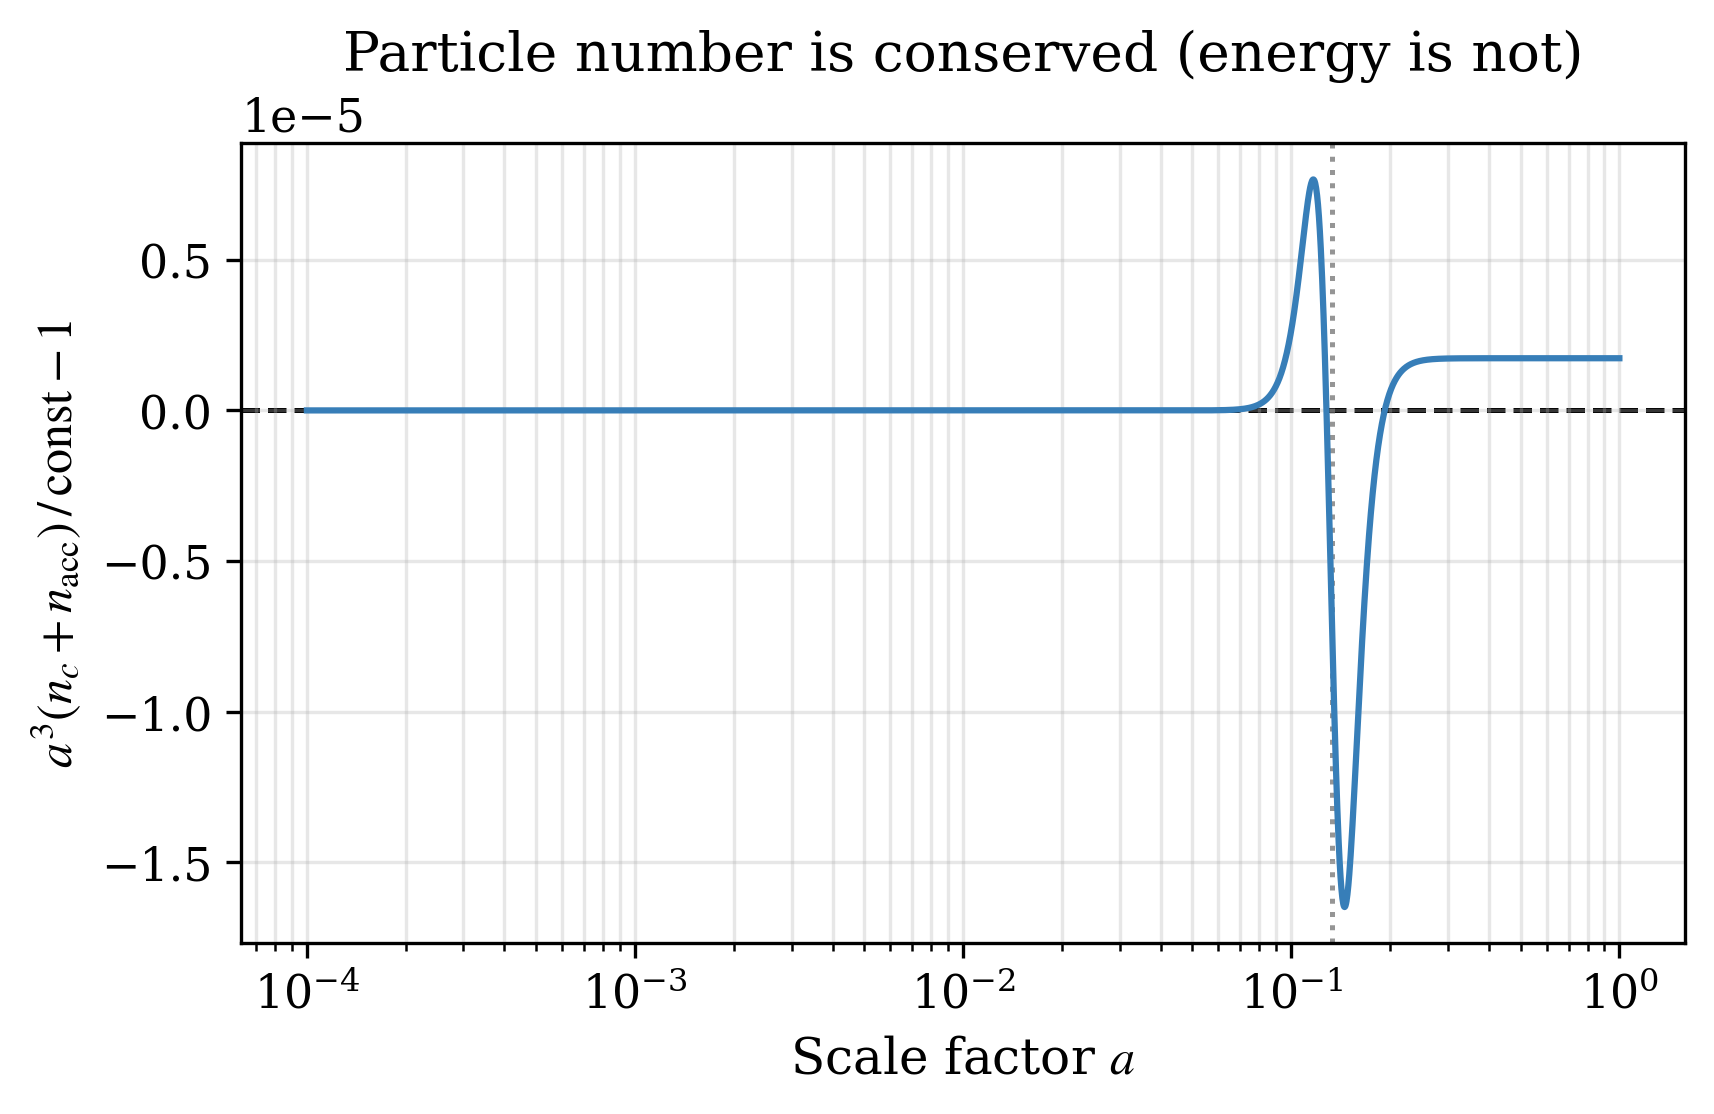

In [11]:
a_g   = tab_acc['a']
kern  = a_g**2*tab_acc['gamma_acc']*tab_acc['rho_parent']/tab_acc['H']
N_cum = cumtrapz0(kern, a_g)
comoving_number = a_g**3*tab_acc['rho_parent'] + N_cum

ref  = float(comoving_number[0])
frac = comoving_number/ref - 1.0
print('a^3 (n_c + n_acc) * m_c , normalised to its value at a = {:.1e}'.format(a_g[0]))
print('  max drift  : {:.3e}'.format(float(np.max(np.abs(frac)))))
print('  drift at 1 : {:+.3e}'.format(float(frac[-1])))
number_ok = float(np.max(np.abs(frac))) < 1e-3
print('  number conservation:', 'PASS' if number_ok else 'CHECK - drift above 1e-3')

fig, ax = plt.subplots(figsize=(5.6, 3.6), constrained_layout=True)
ax.semilogx(a_g, frac, color=qual_colors[0])
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$a^3(n_c+n_{\mathrm{acc}})\,/\,\mathrm{const} - 1$')
ax.set_title('Particle number is conserved (energy is not)')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## 7. $c_g^2$ pole check

**Separate issue, report separately.** The adiabatic sound speed used by the fluid approximation is

$$c_g^2 = w\,\frac{5 - \tilde p/P - \dfrac{\eta(\eta+2)}{3w(1+\eta)}\hat Q}{3(1+w) - (1+\eta)\hat Q},
\qquad \hat Q = \frac{aQ_0}{\mathcal{H}\rho_{\rm acc}} = \frac{\Gamma_{\rm acc}}{H}\frac{\rho_c}{\rho_{\rm acc}} .$$

The denominator is proportional to $\rho_{\rm acc}'$ and therefore **passes through zero wherever
$\rho_{\rm acc}$ peaks**. The code evaluates this at `background.c:3052` and at four places in
`perturbations.c` (`7374`, `8794`, `8886`, `11382`); three of them have a near-singularity fallback
to the source-free $c_g^2$, and `perturbations.c:7355` does not (see the standing audit note). This
cell finds the crossings from the background table.


c_g^2 denominator 3(1+w) - (1+eta)*Qhat, fiducial point
  zero crossings          : 1
  crossing scale factors  : [0.14501]
  min |denominator|       : 8.8181e-03 at a = 0.14548
  c_g^2 range             : [-4.3817e-01, 4.5271e+00]
  negative c_g^2 anywhere : True
  source-dominated limit eta(eta+2)/(3(1+eta)^2) = v_inj^2/3 : 0.057851


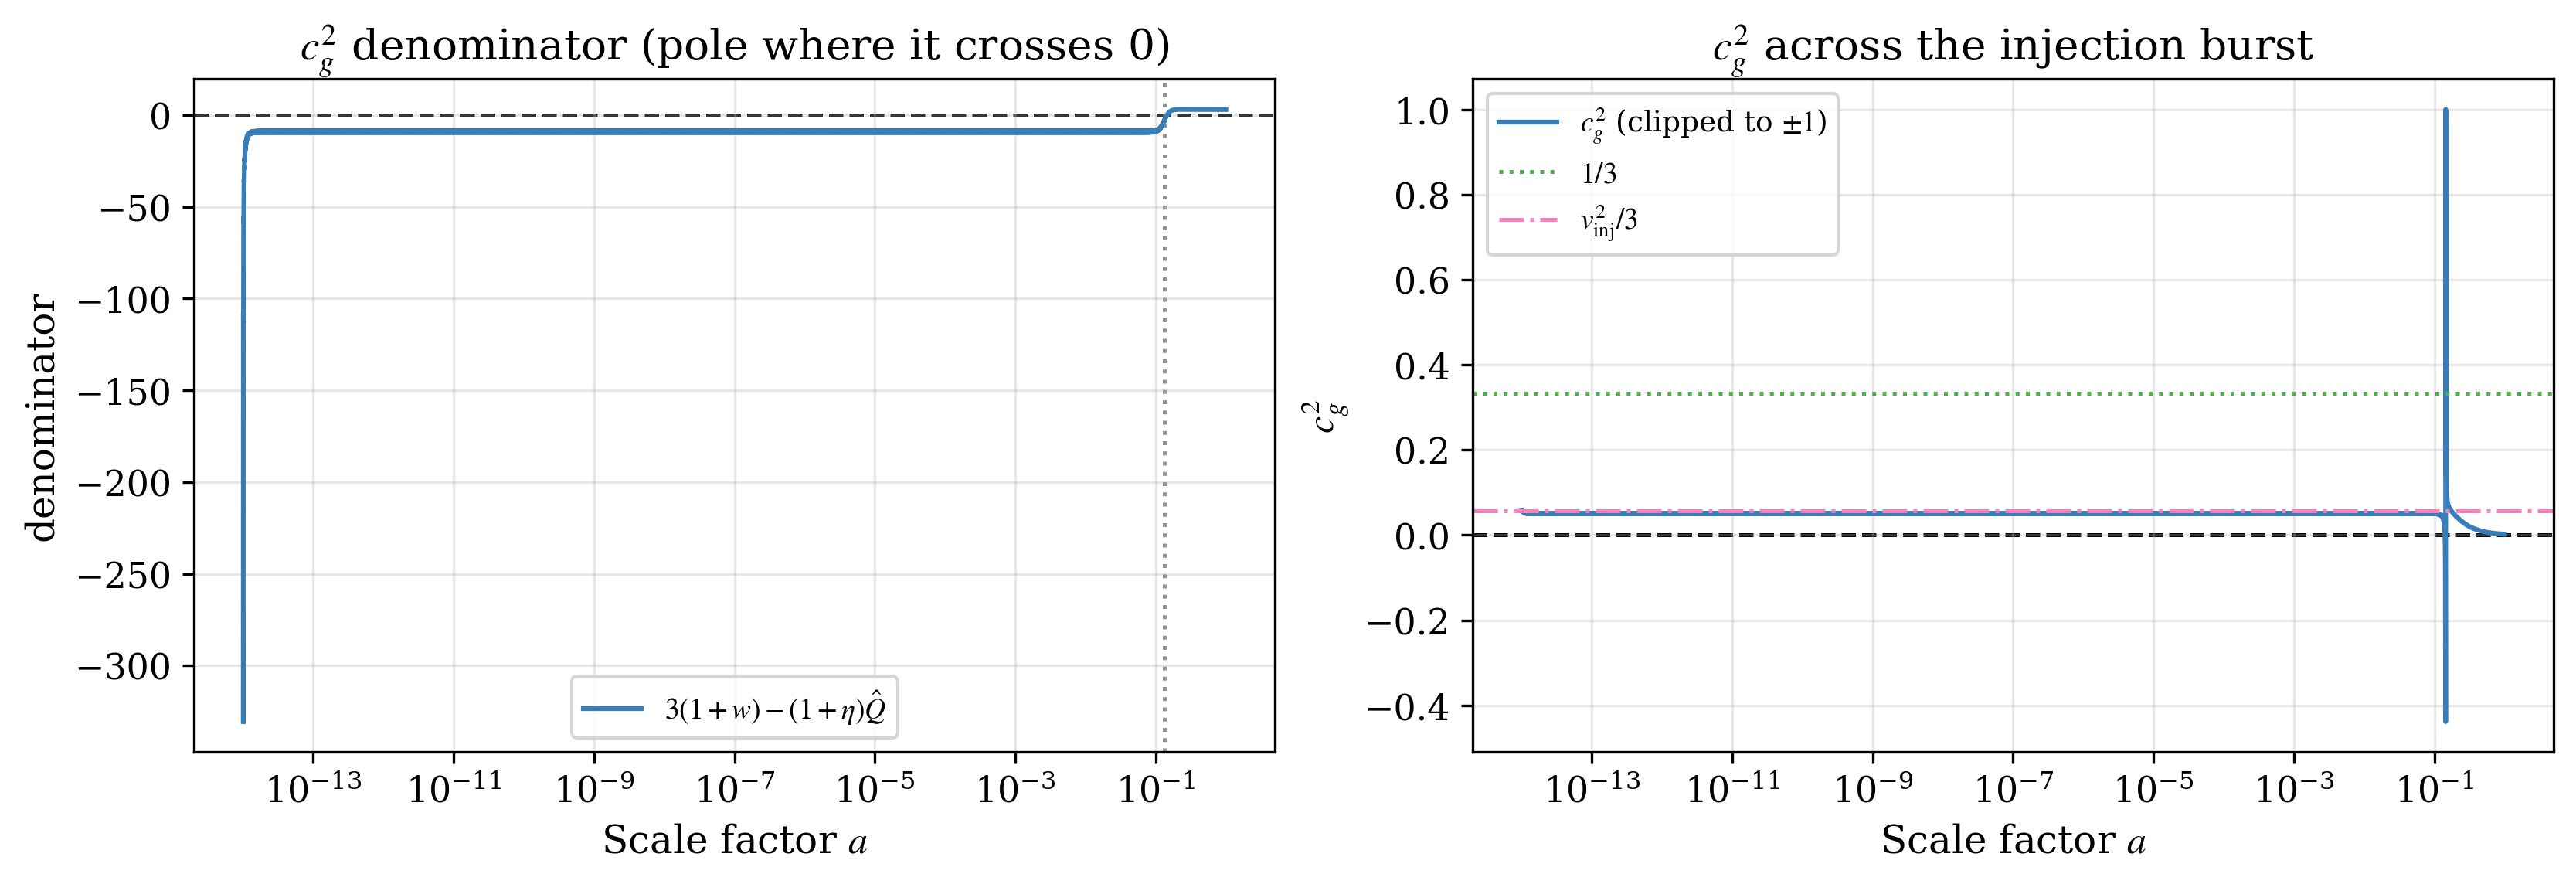

In [12]:
def cg2_denominator(bg, eta):
    d = daughter_index(bg)
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    o = np.argsort(a_all)
    take = lambda k: np.asarray(bg[k])[o]
    a      = a_all[o]
    rho_d  = take('(.)rho_ncdm[{:d}]'.format(d))
    p_d    = take('(.)p_ncdm[{:d}]'.format(d))
    pp_d   = take('(.)pseudo_p_ncdm[{:d}]'.format(d))
    rho_c  = take('(.)rho_acc_cdm')
    gamma  = take('Gamma_acc')
    H      = take('H [1/Mpc]')
    ok = (rho_d > 0) & (p_d > 0)
    a, rho_d, p_d, pp_d, rho_c, gamma, H = (v[ok] for v in (a, rho_d, p_d, pp_d, rho_c, gamma, H))
    w     = p_d/rho_d
    Qhat  = (gamma/H)*(rho_c/rho_d)
    num   = w*(5.0 - pp_d/p_d) - Qhat*(eta*eta + 2*eta)/(3.0*(1.0 + eta))
    den   = 3.0*(1.0 + w) - (1.0 + eta)*Qhat
    return a, num, den, num/den, w, Qhat


a_c, num_c, den_c, cg2_c, w_c, Qhat_c = cg2_denominator(bg_acc, eta_fid)
sign_change = np.where(np.sign(den_c[:-1]) != np.sign(den_c[1:]))[0]
print('c_g^2 denominator 3(1+w) - (1+eta)*Qhat, fiducial point')
print('  zero crossings          : {:d}'.format(len(sign_change)))
if len(sign_change):
    print('  crossing scale factors  :', np.round(a_c[sign_change], 5))
print('  min |denominator|       : {:.4e} at a = {:.5f}'.format(
      float(np.min(np.abs(den_c))), float(a_c[int(np.argmin(np.abs(den_c)))])))
print('  c_g^2 range             : [{:.4e}, {:.4e}]'.format(float(np.min(cg2_c)), float(np.max(cg2_c))))
print('  negative c_g^2 anywhere : {}'.format(bool(np.any(cg2_c < 0))))
print('  source-dominated limit eta(eta+2)/(3(1+eta)^2) = v_inj^2/3 : {:.6f}'.format(
      eta_fid*(eta_fid + 2.0)/(3.0*(1.0 + eta_fid)**2)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
ax = axes[0]
ax.semilogx(a_c, den_c, color=qual_colors[0], label=r'$3(1+w)-(1+\eta)\hat Q$')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel('denominator')
ax.set_title(r'$c_g^2$ denominator (pole where it crosses 0)')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogx(a_c, np.clip(cg2_c, -1.0, 1.0), color=qual_colors[0], label=r'$c_g^2$ (clipped to $\pm1$)')
ax.axhline(1.0/3.0, color=qual_colors[2], linestyle=':', linewidth=1.2, label=r'$1/3$')
ax.axhline(eta_fid*(eta_fid + 2.0)/(3.0*(1.0 + eta_fid)**2), color=qual_colors[3],
           linestyle='-.', linewidth=1.2, label=r'$v_{\mathrm{inj}}^2/3$')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$c_g^2$')
ax.set_title(r'$c_g^2$ across the injection burst')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## 8. Perturbation-level analogue

The same asymmetry appears as $\sum_i \delta Q_i = \eta\,\delta(aQ_0) \neq 0$: the parent loses
$-a\Gamma\rho_c\delta_c$ (`perturbations.c:9907`) and the daughter gains
$+(1+\eta)a\Gamma\rho_c\delta_c$ (`perturbations.c:10190`, `10195`).

**The caveat, verified rather than asserted.** CLASS in synchronous gauge *imposes* the energy
constraint to set $h'$ (`perturbations.c:6876-6877`):

$$h' = \frac{k^2\eta + \tfrac32 a^2\,\delta\rho_{\rm tot}}{\tfrac12\mathcal{H}},\qquad\text{and}\qquad
k^2\eta' = \tfrac32 a^2 (\rho+p)\theta \quad (\texttt{perturbations.c:6900}).$$

so the residual of $k^2\eta - \tfrac12\mathcal{H}h' + \tfrac32 a^2\delta\rho_{\rm tot}$ is **zero by
construction** and carries no information. The first cell below confirms this at machine precision -
that is the task's warning made concrete, and it doubles as a null test of the units and
interpolation used in this section. (Note CLASS density units already absorb $8\pi G/3$, so
$4\pi G a^2\delta\rho_{\rm phys} = \tfrac32 a^2\delta\rho_{\rm CLASS}$.)

The equation that is *not* imposed is the trace equation for $h''$, and evaluating it needs
$\delta p_{\rm tot}$, which is not exported. **A faithful section-5 residual therefore needs one
small instrumentation change**: store `ppw->delta_p` next to `ppw->delta_rho` in the
`k_output_values` columns (`perturbations.c:3325+`, alongside the existing `delta_rho_tot` entry),
then monitor $h'' + 2\mathcal{H}h' - 2k^2\eta + 3a^2\,\delta p_{\rm tot}$ (Ma & Bertschinger 21c).

What *is* accessible right now is the direct magnitude of the spurious source. The parent loses
$-a\Gamma\rho_c\delta_c$ and the daughter gains $+(1+\eta)a\Gamma\rho_c\delta_c$, so the fraction of
$\delta\rho_{\rm tot}$ created from nothing per e-fold is

$$\Lambda_{\rm spur}(k,a) \;=\; \frac{\eta\,a\Gamma_{\rm acc}\,\rho_c\,\delta_c}{\mathcal{H}\,\delta\rho_{\rm tot}}
\;=\; \frac{\eta\,\Gamma_{\rm acc}\,\rho_c\,\delta_c}{H\,\delta\rho_{\rm tot}},$$

the perturbation analogue of $2R$ (it reduces to it when $\delta_c = \delta_{\rm tot}$). Its running
integral is the accumulated spurious fraction of $\delta\rho_{\rm tot}$.


In [13]:
# K_OUT = [0.01, 0.1, 1.0]        # 1/Mpc  (k_output_values is in 1/Mpc)
# N_Q_PERT = 250                  # daughter q-bins: the exact hierarchy costs ~O(q_size),
#                                 # and 250 is plenty for a source-magnitude diagnostic

# pert_params = accdm_params(n_q=N_Q_PERT, **FIDUCIAL)
# pert_params.update({'output': 'mPk', 'gauge': 'synchronous',
#                     'k_output_values': ','.join(str(k) for k in K_OUT),
#                     'P_k_max_1/Mpc': 2.0, 'z_max_pk': 3.0})
# cosmo = Class(); cosmo.set(pert_params); cosmo.compute()
# perts = cosmo.get_perturbations()['scalar']
# bg_p  = cosmo.get_background()
# cosmo.struct_cleanup(); cosmo.empty()

# print('available get_perturbations() keys:')
# print(' ', sorted(perts[0].keys()))

# ap    = 1.0/(1.0 + np.asarray(bg_p['z']))
# op    = np.argsort(ap)
# bg_ln = np.log(ap[op])
# interp_bg = lambda key, a_at: np.interp(np.log(a_at), bg_ln, np.asarray(bg_p[key])[op])

# # ---- null test: the synchronous energy constraint is imposed, so its residual is 0 ----
# print('\nEnergy-constraint residual  k^2 eta - (1/2) Hcal h_prime + (3/2) a^2 delta_rho_tot')
# print('(CLASS sets h_prime from exactly this equation -> must be zero by construction)')
# print('  {:>10} {:>16} {:>16}'.format('k [1/Mpc]', 'max |C|/|largest|', 'median |C|/|largest|'))
# for kk, pk in zip(K_OUT, perts):
#     a_k   = np.asarray(pk['a'])
#     sel   = a_k > 1e-6
#     a_k   = a_k[sel]
#     eta_s = np.asarray(pk['eta'])[sel]
#     hp    = np.asarray(pk['h_prime'])[sel]
#     drho  = np.asarray(pk['delta_rho_tot'])[sel]
#     Hcal  = a_k*interp_bg('H [1/Mpc]', a_k)
#     t1, t2, t3 = kk*kk*eta_s, -0.5*Hcal*hp, 1.5*a_k**2*drho
#     scale = np.maximum.reduce([np.abs(t1), np.abs(t2), np.abs(t3)])
#     resid = np.abs(t1 + t2 + t3)/np.where(scale > 0, scale, 1.0)
#     print('  {:>10g} {:>16.3e} {:>16.3e}'.format(kk, float(np.max(resid)), float(np.median(resid))))
# print('  -> as expected: no information here. Use the source magnitude below instead.')


In [14]:
# fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), constrained_layout=True)
# summary_pert = []

# for color, kk, pk in zip(qual_colors, K_OUT, perts):
#     a_k = np.asarray(pk['a'])
#     sel = (a_k > 1e-4) & (a_k <= 1.0)
#     a_k = a_k[sel]
#     delta_parent = np.asarray(pk['delta_dcdm'])[sel]
#     delta_rho    = np.asarray(pk['delta_rho_tot'])[sel]
#     rho_c_k = interp_bg('(.)rho_acc_cdm', a_k)
#     gam_k   = interp_bg('Gamma_acc', a_k)
#     H_k     = interp_bg('H [1/Mpc]', a_k)

#     lam = eta_fid*gam_k*rho_c_k*delta_parent/(H_k*delta_rho)
#     lam = np.where(np.isfinite(lam), lam, 0.0)
#     accum = cumtrapz0(lam, np.log(a_k))

#     axes[0].loglog(a_k, np.abs(lam), color=color,
#                    label=r'$k = {:g}\ \mathrm{{Mpc}}^{{-1}}$'.format(kk))
#     axes[1].semilogx(a_k, accum, color=color,
#                      label=r'$k = {:g}\ \mathrm{{Mpc}}^{{-1}}$'.format(kk))
#     summary_pert.append((kk, float(np.max(np.abs(lam))), float(accum[-1])))

# axes[0].set_ylabel(r'$|\Lambda_{\mathrm{spur}}|$')
# axes[0].set_title(r'Spurious $\delta\rho$ source per e-fold')
# axes[1].set_ylabel(r'$\int \Lambda_{\mathrm{spur}}\,\mathrm{d}\ln a$')
# axes[1].set_title(r'Accumulated spurious fraction of $\delta\rho_{\mathrm{tot}}$')
# axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
# for ax in axes:
#     ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
#     ax.set_xlim(1e-3, 1.0)
#     ax.set_xlabel(r'Scale factor $a$')
#     ax.legend(loc='best')
#     ax.grid(True, which='both', alpha=0.3)
# plt.show()

# print('{:>12} {:>18} {:>22}'.format('k [1/Mpc]', 'max |Lambda_spur|', 'accumulated at a=1'))
# for kk, mx, ac in summary_pert:
#     print('{:>12g} {:>18.4e} {:>22.4e}'.format(kk, mx, ac))


## 9. Verdict


In [15]:
print('=' * 78)
print('STRESS-ENERGY CONSERVATION AUDIT - accDM')
print('=' * 78)
print()
print('Structural finding (section 0, from source):')
print('  Q1 = (1+eta)   Q2 = -1   Q3 = same mass by default   Q4 = no reservoir')
print('  -> the error is PRESENT: the daughter is born with (1+eta)*m_c while the')
print('     parent gives up m_c, and nothing supplies the difference.')
print()
print('LCDM null tests (measured noise floors):')
print('  units self-test   max|H^2/rho_tot - 1| = {:.3e}'.format(tab_lcdm['units_residual']))
print('  D1                max|R_windowed|      = {:.3e}'.format(NULL_R_FLOOR))
print('  D2                |Omega_K_eff(1)|     = {:.3e}'.format(NULL_OMEGAK_FLOOR))
print()
print('accDM, per parameter point (S/N = value / null floor):')
print('{:<24} {:>12} {:>10} {:>8} {:>16} {:>8}'.format(
      'point', 'max|R|', 'at a', 'S/N', 'Omega_K_eff(1)', 'S/N'))
print('-' * 84)
worst_R = 0.0
worst_OmegaK = 0.0
for label, _ in SCAN_POINTS:
    r = scan_results[label]
    worst_R = max(worst_R, r['R_max'])
    worst_OmegaK = max(worst_OmegaK, abs(r['OmegaK1']))
    print('{:<24} {:>12.4e} {:>10.4f} {:>8.1e} {:>+16.4e} {:>8.1e}'.format(
          label, r['R_max'], r['a_at_max'], r['R_max']/max(NULL_R_FLOOR, 1e-300),
          r['OmegaK1'], abs(r['OmegaK1'])/max(NULL_OMEGAK_FLOOR, 1e-300)))
print()
print('largest |Omega_K_eff(1)| = {:.3e}   vs Planck 2018+BAO  Omega_K = 0.0007 +/- 0.0019'.format(
      worst_OmegaK))
print('  -> {:.1f} sigma of the Planck curvature bound'.format(worst_OmegaK/0.0019))
print()

if worst_R < 1e-6:
    verdict = 'below 1e-6  -> integrator noise: document the structure, add the null test, move on'
elif worst_R < 1e-4:
    verdict = '1e-6 to 1e-4 -> real but almost certainly unobservable: quantify C_l/P(k) once, state it, move on'
elif worst_R < 1e-2:
    verdict = '1e-4 to 1e-2 -> potentially observable and degenerate with the signal: quantify impact; fix + refit likely'
else:
    verdict = 'above 1e-2  -> invalidates parameter inference: fix and rerun'
print('worst max|R| over the scanned points = {:.3e}'.format(worst_R))
print('DECISION TABLE (section 7 of the brief):', verdict)
print()
print('Reminder: the impact comparison that matters is current code vs a FIXED version,')
print('not accDM vs LCDM, because kappa controls both the physical free-streaming')
print('suppression and the spurious injection through the same eta.')
print()
print('Also flagged separately, independent of conservation:')
print('  - c_g^2 denominator crossings at this point: {:d}'.format(len(sign_change)))
print('  - Q0 is a function of background a only; if the trigger is a LOCAL condition,')
print('    delta_Q has a contribution that is absent from the model entirely.')
print('=' * 78)


STRESS-ENERGY CONSERVATION AUDIT - accDM

Structural finding (section 0, from source):
  Q1 = (1+eta)   Q2 = -1   Q3 = same mass by default   Q4 = no reservoir
  -> the error is PRESENT: the daughter is born with (1+eta)*m_c while the
     parent gives up m_c, and nothing supplies the difference.

LCDM null tests (measured noise floors):
  units self-test   max|H^2/rho_tot - 1| = 2.220e-16
  D1                max|R_windowed|      = 4.595e-08
  D2                |Omega_K_eff(1)|     = 1.071e-04

accDM, per parameter point (S/N = value / null floor):
point                          max|R|       at a      S/N   Omega_K_eff(1)      S/N
------------------------------------------------------------------------------------
fiducial                   1.5878e-02     0.1325  3.5e+05      +1.8451e-02  1.7e+02
eta = 1e11/m (default)     4.3886e-03     0.1325  9.6e+04      +1.2721e-04  1.2e+00
aggressive corner          4.8579e-01     0.1325  1.1e+07      +5.0057e-01  4.7e+03
a_t = 0.02              